# A tour of STARfinder segmentation and assignment: the three calls per FOV

This notebook introduces §2.9 of the maintained Python package: segmentation (label masks of
nuclei and cells) and assignment (molecules to cells, nucleus–cell correspondence,
compartments and counts). The code lives in `starfinder.segmentation` and
`starfinder.assignment`, and `FOV` in `starfinder.dataset` coordinates it. The design asks
for a notebook example of **the three calls per field of view (FOV)** (decision D1 of
[docs/segmentation-contract.md](../../docs/segmentation-contract.md), "Settled decisions
this page follows"), and this is that example. Like the §2.6 to §2.8 tours
(`starfinder_registration_tour.ipynb`, `starfinder_spot_finding_tour.ipynb`,
`starfinder_readout_tour.ipynb`), it runs every piece through the public API, on small
synthetic fixtures whose answers are known:

1. the three calls;
2. a synthetic FOV through `FOV.run`;
3. the reference grid;
4. a plan with an imported nucleus mask and a seeded-watershed cell run;
5. assign's expansion, with both masks kept;
6. `FOV.assign` with nuclei;
7. statuses and the count identity;
8. correspondence statuses, flags and withheld compartments;
9. the exclusion and its totals;
10. persistence and reloading;
11. what §2.10 receives;
12. checks and limits;
13. clean up.

Every section first explains a design choice and then runs the code that shows it. The design
is specified in six pages accepted at W-309 (section 1); the notebook links those pages rather
than repeating them. **It is not a benchmark.** It runs no learned model, compares no methods,
recommends no method, threshold or tolerance and makes no accuracy statement: the nucleus
mask is hand-built, the cells come from the seeded watershed at its defaults, and the
correspondence cases use the hand-built `boxes` geometry of the validation design. Every array
is at most 32×64×64 voxels, with four channels and four rounds (section 12 checks it).
Everything runs on one CPU thread, without a GPU.

**Scope and resources.** The scenes are generated in memory. The notebook needs no downloaded
data, MATLAB, GPU, network access or model file. Section 4 has one optional cell that shows a
`stardist` configuration without running it, and prints why it is skipped when StarDist is not
importable. Every random draw comes from a fixed seed and the numerical libraries run on one
thread, so a second execution prints the same numbers on the same host and library build,
except the wall-clock timings that section 12 collects. Files are written only under a
temporary directory that the notebook creates and removes in its last cell.

To execute it from `src/python` in the locked environment (the `dev` group provides Jupyter),
with one numerical thread and no GPU:

```bash
export OMP_NUM_THREADS=1 MKL_NUM_THREADS=1 OPENBLAS_NUM_THREADS=1 CUDA_VISIBLE_DEVICES=""
uv run jupyter nbconvert --to notebook --execute --output-dir <new directory> \
    ../../example/introduction/starfinder_segmentation_assignment_tour.ipynb
```

The setup cell draws figures inline. It keeps the numerical libraries on one thread (set before
NumPy is imported) and hides any GPU. It checks that `starfinder` is imported from the checkout
that holds this notebook, and that importing the segmentation and assignment modules imports no
learned backend (StarDist, TensorFlow, Cellpose, torch): a learned method imports its backend
only when it runs. Everything the notebook writes goes to a new temporary workspace, which
section 13 removes. The helpers defined here:

* `clean` writes that workspace as `<workspace>`, so no machine-specific path is printed;
* `error_of` prints the error a call raises;
* `timed` records the wall time of the slower steps for section 12;
* `file_sha256` and `files_under` hash files, for the links of section 10.

In [1]:
%matplotlib inline
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS",
                 "NUMBA_NUM_THREADS"):
    os.environ.setdefault(variable, "1")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")

import hashlib
import inspect
import json
import sys
import tempfile
import time
import warnings
from contextlib import contextmanager
from dataclasses import fields, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import starfinder
import starfinder.assignment
import starfinder.dataset
import starfinder.segmentation
import starfinder.synthetic

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 80)

REPOSITORY = Path(starfinder.__file__).resolve().parents[3]
LEARNED_BACKENDS = ("stardist", "tensorflow", "cellpose", "torch")
print("starfinder imported from:", Path(starfinder.__file__).resolve().relative_to(REPOSITORY).as_posix())
print("the same checkout as this notebook:", Path.cwd().resolve().is_relative_to(REPOSITORY))
print("learned backends imported:", {name: name in sys.modules for name in LEARNED_BACKENDS})
print("threads:", {v: os.environ[v] for v in ("OMP_NUM_THREADS", "NUMBA_NUM_THREADS")},
      " CUDA_VISIBLE_DEVICES:", repr(os.environ["CUDA_VISIBLE_DEVICES"]))

_workspace = tempfile.TemporaryDirectory(prefix="starfinder-segmentation-assignment-tour-")
WORKSPACE = Path(_workspace.name)
TIMINGS = {}


def clean(text):
    # Write the temporary workspace as <workspace>.
    return str(text).replace(str(WORKSPACE), "<workspace>")


def show(obj):
    print(clean(obj if isinstance(obj, str) else repr(obj)))


def error_of(call):
    # Run call, which must raise; return "<error type>: <message>" with clean paths.
    try:
        call()
    except Exception as error:
        return clean(f"{type(error).__name__}: {error}")
    raise AssertionError("expected an error")


@contextmanager
def timed(label):
    start = time.perf_counter()
    yield
    TIMINGS[label] = time.perf_counter() - start


def file_sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def files_under(root):
    # {relative path: SHA-256} of every file under root.
    return {p.relative_to(root).as_posix(): file_sha256(p) for p in sorted(Path(root).rglob("*")) if p.is_file()}


print("workspace: a new temporary directory, removed at the end")

starfinder imported from: src/python/starfinder/__init__.py
the same checkout as this notebook: True
learned backends imported: {'stardist': False, 'tensorflow': False, 'cellpose': False, 'torch': False}
threads: {'OMP_NUM_THREADS': '1', 'NUMBA_NUM_THREADS': '1'}  CUDA_VISIBLE_DEVICES: ''
workspace: a new temporary directory, removed at the end


## 1. The three calls

**Terms** ([docs/segmentation-contract.md](../../docs/segmentation-contract.md), "Terms";
[docs/assignment-contract.md](../../docs/assignment-contract.md), "Terms"):

* a **label image** is an integer ZYX image (`uint32`) in which 0 is background and each positive
  value is one object; a plane is 1×Y×X. Its **target** is `nucleus` or `cell`, its **geometry**
  `volume`, `plane` or `extended`;
* the **reference grid** of a FOV is the shape and `ImageMetadata` of its reference round's image
  after `FOV.run`; every label image of the FOV lies on it;
* a **segmentation run** is one named call that yields one label image: a method of
  `SEGMENTATION_METHODS`, or an external mask imported with `import_labels` (an import is not a
  method). **Seeds** are the labels of an earlier run that a method grows from;
* a **molecule** is one accepted read with its spot identity, position and gene; a **territory**
  is the voxels of one cell label that assign samples, either the cell run's labels (original)
  or their expansion by assign (expanded);
* **correspondence** relates nuclei to cells; a **compartment** is the whole cell, its nuclear
  part or its cytoplasmic part.

**D1, separate entries.** Segmentation and assignment are not stages of `FOV.run` and not
fields of `PipelineConfig`. Per FOV there are three calls, each with its own record and files:

1. `fov.run(pipeline, checkpoints=…)`: the molecules (registration, detection, decoding,
   filtering, as in §2.6 to §2.8). It leaves the reference round's image and metadata resident;
2. `fov.segment(plan, checkpoints=…)`: the label masks. It builds each run's input from the
   reference-frame images and runs the plan;
3. `fov.assign(config, cells=…, nuclei=…, checkpoints=…)`: the cell table and counts.

When a plan's inputs come from morphology rounds (a DAPI or Flamingo stain acquired in an
additional round), the caller loads those rounds and calls `fov.register_rounds(recipe,
rounds=[…])` between the first two calls, to bring them into the reference frame through their
shared stain. That is a coordination step, not a fourth call. This tour's plan uses only the
reference round and an imported mask, so it does not need it (section 4).

The cell prints the methods of `FOV` that carry the three calls, the coordination step and the
reloads, with their signatures, and checks that `PipelineConfig` has no segmentation or
assignment field.

In [2]:
from starfinder.dataset import FOV, PipelineConfig

calls = pd.DataFrame([
    dict(role="1. molecules", method="FOV.run", stores="spot_result … filtering_result", signature=FOV.run),
    dict(role="2. label masks", method="FOV.segment", stores="segmentation_results[run]", signature=FOV.segment),
    dict(role="3. cell table and counts", method="FOV.assign", stores="assignment_results[name]",
         signature=FOV.assign),
    dict(role="the grid of every label image", method="FOV.reference_grid", stores="",
         signature=FOV.reference_grid),
    dict(role="coordination step (morphology rounds)", method="FOV.register_rounds", stores="images[round]",
         signature=FOV.register_rounds),
    dict(role="reload a segmentation run", method="FOV.load_segmentation", stores="segmentation_results[run]",
         signature=FOV.load_segmentation),
    dict(role="reload an assignment", method="FOV.load_assignment", stores="assignment_results[name]",
         signature=FOV.load_assignment),
])
calls["signature"] = [str(inspect.signature(f)).replace("(self, ", "(").replace("(self)", "()")
                      for f in calls.signature]
with pd.option_context("display.max_colwidth", 400):
    display(calls)
pipeline_fields = [f.name for f in fields(PipelineConfig)]
print("PipelineConfig fields:", pipeline_fields)
print("a segmentation or assignment field in PipelineConfig:",
      any("segment" in name or "assign" in name for name in pipeline_fields))

,role,method,stores,signature
0,1. molecules,FOV.run,spot_result … filtering_result,"(config: 'PipelineConfig', *, execution: 'ExecutionConfig' = ExecutionConfig(mode='batch', retain_images=False, device='cpu'), checkpoints: 'CheckpointConfig | None' = None)"
1,2. label masks,FOV.segment,segmentation_results[run],"(plan: 'SegmentationPlan', *, device: 'str' = 'cpu', checkpoints: 'CheckpointConfig | None' = None) -> 'FOV'"
2,3. cell table and counts,FOV.assign,assignment_results[name],"(config: 'AssignmentConfig | None' = None, *, cells: 'str | SegmentationResult' = 'cell', nuclei: 'str | SegmentationResult | None' = None, name: 'str' = 'default', population: 'str' = 'final', correspondence: 'pd.DataFrame | None' = None, checkpoints: 'CheckpointConfig | None' = None) -> 'FOV'"
3,the grid of every label image,FOV.reference_grid,,() -> 'ReferenceGrid'
4,coordination step (morphology rounds),FOV.register_rounds,images[round],"(recipe: 'RegistrationRecipe', *, rounds: 'Sequence[str]', reference: 'str | ExternalReference | None' = None) -> 'FOV'"
5,reload a segmentation run,FOV.load_segmentation,segmentation_results[run],"(name: 'str', *, checkpoints: 'CheckpointConfig' = CheckpointConfig(stages=('registered', 'candidates', 'pre_qc'), directory=None, table_format='csv', hash_inputs=True, overwrite=False)) -> 'SegmentationResult'"
6,reload an assignment,FOV.load_assignment,assignment_results[name],"(name: 'str', *, checkpoints: 'CheckpointConfig' = CheckpointConfig(stages=('registered', 'candidates', 'pre_qc'), directory=None, table_format='csv', hash_inputs=True, overwrite=False)) -> 'AssignmentResult'"


PipelineConfig fields: ['load', 'rotation_degrees', 'preprocessing', 'registration', 'spot_finding', 'extraction', 'decoding', 'filtering', 'scoring', 'deduplication']
a segmentation or assignment field in PipelineConfig: False


**Where the accepted pages live.** The design is in six pages, accepted at W-309 on 2026-10-05.
The cell prints their titles and status lines from the files:

* [docs/segmentation-baseline.md](../../docs/segmentation-baseline.md) and
  [docs/assignment-baseline.md](../../docs/assignment-baseline.md) record the legacy behavior,
  with the two golden tests;
* [docs/segmentation-contract.md](../../docs/segmentation-contract.md) holds the label image,
  the segment entry and its coordination per FOV, the registry, import, the label functions,
  models, devices and the saved format;
* [docs/assignment-contract.md](../../docs/assignment-contract.md) holds the assign entry,
  sampling, statuses, expansion, correspondence, compartments, the exclusion, the cell table,
  the count accounting, persistence and the boundary with §2.10;
* [docs/segmentation-algorithms.md](../../docs/segmentation-algorithms.md) and
  [docs/assignment-algorithms.md](../../docs/assignment-algorithms.md) hold the numerical rules
  and the engineering validation design (checks L1 to L14 and A1 to A20).

In [3]:
for page in ("segmentation-baseline", "segmentation-contract", "segmentation-algorithms", "assignment-baseline",
             "assignment-contract", "assignment-algorithms"):
    lines = (REPOSITORY / "docs" / f"{page}.md").read_text().splitlines()
    status = next(line for line in lines if line.startswith("Status:"))
    print(f"docs/{page}.md: {lines[0].lstrip('# ')}\n    {status}")

docs/segmentation-baseline.md: Segmentation baseline: morphology inputs, StarDist and label files
    Status: Accepted (W-309, 2026-10-05, at 3550723)
docs/segmentation-contract.md: Segmentation contract: label images, methods, inputs and environments
    Status: Accepted (W-309, 2026-10-05, at 3550723)
docs/segmentation-algorithms.md: Segmentation algorithm specification
    Status: Accepted (W-309, 2026-10-05, at 3550723)
docs/assignment-baseline.md: Assignment baseline: molecules to cells, counts and the sample tables
    Status: Accepted (W-309, 2026-10-05, at 3550723)
docs/assignment-contract.md: Assignment contract: molecules to cells, correspondence, compartments and counts
    Status: Accepted (W-309, 2026-10-05, at 3550723)
docs/assignment-algorithms.md: Assignment algorithm specification and §2.9 validation design
    Status: Accepted (W-309, 2026-10-05, at 3550723)


## 2. A synthetic FOV through `FOV.run`

The FOV is the development calibration's scene (`calibrated_scene_preset` of
`calibrated-development-v1`, condition `clean`, seed 103, the seed of the §2.8 tour): one
8×64×64 `uint8` field of view with four rounds and four channels and 80 amplicons of a balanced
16-gene codebook. These amplicons are molecules, not cells: the §2.12 scenes hold no nuclei,
cells or membranes, so nothing below derives a cell or a nucleus from them
([docs/assignment-algorithms.md](../../docs/assignment-algorithms.md), "Engineering validation
design"). The generator warns how many voxel values it clipped to the `uint8` range; the cell
records and prints each warning.

The generator records no voxel size. The seeded watershed needs one (its smoothing is in µm),
and a calibrated grid makes the cell sizes physical, so the notebook declares the spacing of the
validation design's `boxes` fixture, 0.35 × 0.1 × 0.1 µm (ZYX), on every round. This is a
declaration for the demonstration, not a measured pixel size.

The first call runs the §2.8 pipeline on the resident rounds: local maxima at their defaults on
the reference round, extraction with the default box and local background, the WTA decoder, the
shared score and the default filter, with every checkpoint stage written to the workspace. The
molecules of assignment are the accepted reads (`population="final"`, the goodSpots
population), joined with their spots by `molecule_table`, as `FOV.assign` will do.

In [4]:
from starfinder.assignment import molecule_table
from starfinder.barcode import NeighborhoodSumConfig, ReadFilterConfig, ReadScoreConfig, WtaDecoderConfig
from starfinder.dataset import CheckpointConfig, Dataset, RoundState
from starfinder.spot_finding import LocalMaximaConfig
from starfinder.synthetic import calibrated_scene_preset, generate_formed_scene

SEED = 103
SPACING_ZYX = (0.35, 0.1, 0.1)
with timed("generate the scene (clean, seed 103, 8x64x64x4, 4 rounds)"):
    book, scene_config = calibrated_scene_preset("clean", seed=SEED)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        scene = generate_formed_scene(book, config=scene_config)
for warning in caught:
    print(f"{warning.category.__name__} from generate_formed_scene: {warning.message}")
ROUNDS = tuple(scene.round_labels)
METADATA = replace(scene.metadata, spacing_zyx=SPACING_ZYX, spatial_unit="micrometer")
print("scene:", scene_config.dataset_version, " seed:", scene_config.seed, " amplicons:", len(scene.amplicon_ids))
print("rounds:", {label: f"{image.shape} {image.dtype}" for label, image in scene.rounds.items()})
print("codebook:", book)
print("declared metadata:", METADATA)

CHECKPOINTS = CheckpointConfig(directory=WORKSPACE / "checkpoints")
PIPELINE = PipelineConfig(spot_finding=LocalMaximaConfig(), extraction=NeighborhoodSumConfig(),
                          decoding=WtaDecoderConfig(), scoring=ReadScoreConfig(), filtering=ReadFilterConfig())
(WORKSPACE / "data").mkdir()
dataset = Dataset(WORKSPACE / "data", WORKSPACE / "data" / "out", "tour", "synthetic", "out",
                  rounds=RoundState(sequencing_rounds=list(ROUNDS), reference_round=ROUNDS[0]),
                  channel_order=list(book.channel_labels))
dataset.codebook = book
fov = dataset.fov("FOV_001")
fov.images = {label: image.copy() for label, image in scene.rounds.items()}
fov.metadata = {label: METADATA for label in ROUNDS}
with timed("call 1: FOV.run with checkpoints"):
    fov.run(PIPELINE, checkpoints=CHECKPOINTS)
print()
print(fov)
molecules = molecule_table(fov.spot_result, fov.filtering_result, genes=book.genes)
print("\nmolecules (accepted reads):", len(molecules.table), " population:", molecules.population,
      " genes:", len(molecules.genes))
print("MoleculeTable.sha256:", molecules.sha256)
RUN_FILES = files_under(CHECKPOINTS.directory)
print("files of FOV.run:", sorted(RUN_FILES))

RuntimeWarning from generate_formed_scene: round round1: 26542 of 131072 voxel values (20.2%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round2: 22795 of 131072 voxel values (17.4%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round3: 23919 of 131072 voxel values (18.2%) were clipped to the uint8 range
RuntimeWarning from generate_formed_scene: round round4: 23834 of 131072 voxel values (18.2%) were clipped to the uint8 range
scene: calibrated-development-v1-clean-balanced  seed: 103  amplicons: 80
rounds: {'round1': '(8, 64, 64, 4) uint8', 'round2': '(8, 64, 64, 4) uint8', 'round3': '(8, 64, 64, 4) uint8', 'round4': '(8, 64, 64, 4) uint8'}
codebook: Codebook: 16 genes × 4 rounds, channels ch00, ch01, ch02, ch03; encoding two_base, one segment of 4 colors
declared metadata: ImageMetadata(frame_id='["calibrated-development-v1-clean-balanced","synthetic","FOV_001","formed"]/reference', spacing_zyx=(0.35, 0.1, 0.1),


FOV 'FOV_001' of Dataset 'tour' (sample 'synthetic')
    images:   round1*, round2, round3, round4 — (8, 64, 64, 4) uint8 ZYXC   (* reference)
    channels: ch00, ch01, ch02, ch03
    results:  spot_finding, extraction, decoding, scoring, filtering
      spot_finding  69 spots × [spot_id, z, y, x, ...]
      extraction    69 spots × 4 channels × 4 rounds
      decoding      69 reads — assigned 63, unmatched 6
      scoring       63 of 69 reads scored — no_assignment 6
      filtering     63 accepted / 69 (91.3%), rejected 6 — call_status 6

molecules (accepted reads): 63  population: final  genes: 16
MoleculeTable.sha256: 46cbca1ba001e471ac5bdd92700989a8ac7946b513a28d0c67a3c5598983dee1
files of FOV.run: ['FOV_001/candidates.csv', 'FOV_001/candidates.json', 'FOV_001/pre_qc.csv', 'FOV_001/pre_qc.json', 'FOV_001/registered/round1.ome.tif', 'FOV_001/registered/round2.ome.tif', 'FOV_001/registered/round3.ome.tif', 'FOV_001/registered/round4.ome.tif', 'FOV_001/registered/transforms.json', '

## 3. The reference grid

`ImageMetadata` carries no shape, so the grid is its own object, `ReferenceGrid`: the Z, Y, X
sizes, the metadata (frame, spacing, origin, direction), a source and the SHA-256 of the image it
was read from ([docs/segmentation-contract.md](../../docs/segmentation-contract.md),
"Coordination per FOV"). `FOV.reference_grid()` returns the grid of the resident reference round
(source `fov:<round>`). Every segmentation run of this FOV is on it, and assign checks the label
images against it before it samples anything. `grid.projected()` is the Z=1 grid of a projected
run.

When the reference image is not resident, `reference_grid_from_file` reads the grid from
`images/ref_merged/{fovID}.tif`, which `FOV.save_reference_image` writes. Its hash is that of
the merged image (the channel maximum), not of the four-channel round, so the cell compares the
shape and the metadata, which are what assign checks.

In [5]:
from starfinder.segmentation import reference_grid_from_file

grid = fov.reference_grid()
print("shape_zyx:", grid.shape_zyx)
print("metadata:", grid.metadata)
print("source:", grid.source, " sha256:", grid.sha256)
calibrated = grid.metadata.spacing_zyx is not None and grid.metadata.spatial_unit is not None
print("calibrated:", calibrated)
print("projected:", grid.projected().shape_zyx, grid.projected().metadata.frame_id)
from_file = reference_grid_from_file(fov.save_reference_image())
print("\nfrom the saved reference image:", clean(from_file.source))
print("  same shape:", from_file.shape_zyx == grid.shape_zyx, " same metadata:", from_file.metadata == grid.metadata)

shape_zyx: (8, 64, 64)
metadata: ImageMetadata(frame_id='["calibrated-development-v1-clean-balanced","synthetic","FOV_001","formed"]/reference', spacing_zyx=(0.35, 0.1, 0.1), origin_zyx=None, direction_zyx=None, spatial_unit='micrometer')
source: fov:round1  sha256: a138e329d24165f4103db7c908497912352fca22bb869a3f28f5547680078aef
calibrated: True
projected: (1, 64, 64) ["calibrated-development-v1-clean-balanced","synthetic","FOV_001","formed"]/reference/projection:max

from the saved reference image: file:<workspace>/data/out/images/ref_merged/FOV_001.tif
  same shape: True  same metadata: True


## 4. A plan with an imported nucleus mask and a seeded-watershed cell run

**The nucleus mask** is hand-built: the nuclei of the validation design's `boxes` fixture
([docs/assignment-algorithms.md](../../docs/assignment-algorithms.md), "Fixtures"; section 8
uses the whole fixture), with every Y and X bound doubled so that the seven boxes spread over the
64×64 field. It is written as a TIFF with the grid's metadata, as a mask made by another tool
would be, and enters through `import_labels` (D3: import is not a method). Import reads the
file, converts its dtype to `uint32` (refusing floats, booleans, negative values and values that
do not fit), checks its shape and stored metadata against the grid, and records the file's
SHA-256 and the array's.

**The plan** has two runs (option T1: one run per target). The first imports the same file as
the run `nucleus`. The second, `cell`, runs `seeded_watershed` on the amplicon signal (the
channel maximum of the reference round, `InputChannel("amplicon", reference_merged=True)`, as in
the tissue-2D context) with the nucleus run as its seeds. The watershed smooths the stain by
`sigma_um`, thresholds it (Otsu by default) and grows each seed through the foreground; every
cell carries the value of the nucleus it grew from, and a seed outside the foreground stays a
cell equal to its seed ([docs/segmentation-algorithms.md](../../docs/segmentation-algorithms.md),
"`seeded_watershed`"). The config is at its defaults; `sigma_um` = 1.5 µm is the provisional
default, not a recommendation. Neither run uses a morphology round, so `FOV.register_rounds` is
not called.

`FOV.segment(plan, checkpoints=…)` writes each run under `segmentation/<run>/`: `labels.tif`
(ZYX `uint32` with the grid's metadata), `segmentation.json` (the run record) and, for a method
run, `input.ome.tif` (the segmentation input). The cell run's record holds `input.sha256`, the
SHA-256 of its input's C-order bytes, so the labels can be checked against the image they were
computed from.

In [6]:
from starfinder.io import save_volume
from starfinder.segmentation import (InputChannel, LabelImportConfig, SeededWatershedConfig, SegmentationPlan,
                                     SegmentationRun, import_labels)

# The boxes nuclei: half-open (z, y, x) ranges on the 8x32x32 boxes grid (docs/assignment-algorithms.md, "Fixtures").
NUCLEUS_BOXES = {
    11: ((3, 6), (2, 5), (2, 5)),
    21: ((3, 6), (2, 5), (10, 12)),
    22: ((3, 6), (2, 5), (14, 16)),
    31: ((2, 7), (10, 15), (4, 8)),
    51: ((4, 5), (12, 13), (14, 24)),
    61: ((4, 5), (22, 23), (2, 12)),
    91: ((3, 6), (29, 31), (29, 31)),
}
SCALE_YX = 2


def paint(boxes, shape, scale_yx=1):
    # A uint32 label image with each box set to its value; Y and X bounds multiplied by scale_yx.
    labels = np.zeros(shape, np.uint32)
    for value, ((z0, z1), (y0, y1), (x0, x1)) in boxes.items():
        labels[z0:z1, y0 * scale_yx:y1 * scale_yx, x0 * scale_yx:x1 * scale_yx] = value
    return labels


def label_namespace(spot_namespace, run):
    # [dataset_id, sample_id, fov_id, subtile_id, run], built like the spot namespace.
    return json.dumps([*json.loads(spot_namespace), run], separators=(",", ":"))


nucleus_mask = paint(NUCLEUS_BOXES, grid.shape_zyx, SCALE_YX)
NUCLEUS_FILE = WORKSPACE / "masks" / "nuclei.tif"
save_volume(nucleus_mask, NUCLEUS_FILE, metadata=grid.metadata)
imported = import_labels(NUCLEUS_FILE, grid=grid, target="nucleus",
                         label_namespace=label_namespace(fov.spot_result.spot_namespace, "nucleus"))
print("import_labels:", imported.target, imported.geometry, " labels:", imported.n_labels, " values:",
      np.unique(imported.labels[imported.labels > 0]).tolist(), " outcome:", imported.record["outcome"])
print("  label_namespace:", imported.label_namespace)
print("  import entry:", clean({k: imported.record["import"][k] for k in ("path", "source_dtype", "source_shape",
                                                                           "metadata_source", "relabel")}))

WATERSHED = SeededWatershedConfig()
PLAN = SegmentationPlan((
    SegmentationRun("nucleus", "nucleus", (), LabelImportConfig(str(NUCLEUS_FILE), "nucleus")),
    SegmentationRun("cell", "cell", (InputChannel("amplicon", reference_merged=True),), WATERSHED, seeds="nucleus"),
))
print("\nwatershed config:", WATERSHED)
with timed("call 2: FOV.segment (import and seeded_watershed) with checkpoints"):
    fov.segment(PLAN, checkpoints=CHECKPOINTS)
for name, run in fov.segmentation_results.items():
    print(f"run {name!r}: target {run.target}, geometry {run.geometry}, labels {run.labels.shape} {run.labels.dtype}, "
          f"{run.n_labels} objects (max {run.max_label}), outcome {run.record['outcome']}, "
          f"methods {[m['method'] for m in run.record['methods']]}")
cell = fov.segmentation_results["cell"]
nucleus_run = fov.segmentation_results["nucleus"]
print("\nthe nucleus run equals the import_labels result:", np.array_equal(nucleus_run.labels, imported.labels),
      " same namespace:", nucleus_run.label_namespace == imported.label_namespace)
cell_input = cell.record["input"]
print("cell run input: shape_zyxc", cell_input["shape_zyxc"], cell_input["dtype"], " channels:",
      [{k: c[k] for k in ("role", "round", "reference_merged")} for c in cell_input["channels"]])
print("cell run record input.sha256:", cell_input["sha256"])
seeds = cell.record["seeds"]
print("cell run seeds:", {k: seeds[k] for k in ("run", "label_rule")},
      " sha256 is the nucleus run's labels sha256:", seeds["sha256"] == nucleus_run.record["labels"]["sha256"])
(method,) = cell.record["methods"]
print("cell run method:", method["method"], " effective:", method["effective"])
print("watershed counts:", cell.diagnostics["details"]["counts"])
values, sizes = np.unique(cell.labels[cell.labels > 0], return_counts=True)
print("cells and their sizes (voxels):", dict(zip(values.tolist(), sizes.tolist())))
seed_voxels = nucleus_mask > 0
print("cells equal to their seed:", [v for v in NUCLEUS_BOXES if np.array_equal(cell.labels == v, nucleus_mask == v)])
print("\nevery cell value is a seed value:", set(np.unique(cell.labels).tolist()) - {0} == set(NUCLEUS_BOXES))
print("every seed voxel keeps its seed's value:", np.array_equal(cell.labels[seed_voxels], nucleus_mask[seed_voxels]))
print("files of FOV.segment:", sorted(p for p in files_under(CHECKPOINTS.directory) if p not in RUN_FILES))

import_labels: nucleus volume  labels: 7  values: [11, 21, 22, 31, 51, 61, 91]  outcome: ok
  label_namespace: ["tour","synthetic","FOV_001",null,"nucleus"]
  import entry: {'path': '<workspace>/masks/nuclei.tif', 'source_dtype': 'uint32', 'source_shape': [8, 64, 64], 'metadata_source': 'stored', 'relabel': False}

watershed config: SeededWatershedConfig(sigma_um=1.5, threshold='otsu', compactness=0.0, connectivity=1, method='seeded_watershed')
run 'nucleus': target nucleus, geometry volume, labels (8, 64, 64) uint32, 7 objects (max 91), outcome ok, methods []
run 'cell': target cell, geometry volume, labels (8, 64, 64) uint32, 7 objects (max 91), outcome ok, methods ['seeded_watershed']

the nucleus run equals the import_labels result: True  same namespace: True
cell run input: shape_zyxc [8, 64, 64, 1] uint8  channels: [{'role': 'amplicon', 'round': None, 'reference_merged': True}]
cell run record input.sha256: 274d1e958bf4cbfc61e09e1a2d83735100fa6f455df04ef1d3769d64ca4efa01
cell run

Seeds 11, 21 and 91 lie entirely outside the Otsu foreground of the smoothed amplicon signal
(the watershed's counts list them), so they stay cells equal to their seeds. Seed 22 has only one
voxel in the foreground, and the foreground voxels next to it went to cell 51, so cell 22 also
equals its seed. Cells 31, 51 and 61 grow through the foreground until they meet. This is how the
watershed behaves on this stain at its default smoothing; it says nothing about how well it finds
cells.

**Optional: a `stardist` configuration.** A learned method would take the place of the import
in the plan, for example `StarDistConfig` with a user-trained 3D model given by path, on a
`nuclear` channel of a registered DAPI round. The next cell builds such a configuration and its
run and prints the registry's declared capabilities, **without running it**: it loads no model,
resolves no file and imports neither StarDist nor TensorFlow (the config is validated without
its backend). It is skipped, with the reason printed, when StarDist is not importable here.

In [7]:
import importlib.util

from starfinder.segmentation import SEGMENTATION_METHODS, StarDistConfig

if importlib.util.find_spec("stardist") is None:
    print("skipped: StarDist is not importable in this environment (the 'stardist' extra is not installed); "
          "nothing else in the notebook needs it")
else:
    stardist = StarDistConfig(scale=1.0, model_path="<folder of a user-trained 3D model>")
    spec = SEGMENTATION_METHODS[StarDistConfig]
    print("config:", stardist)
    print("registry:", {"name": spec.name, "targets": sorted(spec.targets), "roles": sorted(spec.roles),
                        "seeds": spec.seeds, "dimensions": sorted(spec.dimensions), "models": spec.models,
                        "devices": sorted(spec.devices),
                        "requires": [f"{d.distribution} [{d.extra}]" for d in spec.requires]})
    print("run:", SegmentationRun("nucleus", "nucleus", (InputChannel("nuclear", round="dapi", channel=0),), stardist))
    print("not run: no model is loaded and no file is resolved")
print("learned backends imported:", {name: name in sys.modules for name in LEARNED_BACKENDS})

config: StarDistConfig(scale=1.0, model=None, model_path='<folder of a user-trained 3D model>', model_sha256=None, prob_thresh=None, nms_thresh=None, normalize_percentiles=(1.0, 99.8), n_tiles=None, block_size=None, min_overlap=None, context=None, method='stardist')
registry: {'name': 'stardist', 'targets': ['cell', 'nucleus'], 'roles': ['composite', 'nuclear'], 'seeds': 'none', 'dimensions': [2, 3], 'models': True, 'devices': ['cpu', 'cuda'], 'requires': ['stardist [stardist]', 'csbdeep [stardist]', 'tensorflow [stardist]']}
run: SegmentationRun(name='nucleus', target='nucleus', inputs=(InputChannel(role='nuclear', round='dapi', channel=0, reference_merged=False, prepare=None, prepare_channel=None),), method=StarDistConfig(scale=1.0, model=None, model_path='<folder of a user-trained 3D model>', model_sha256=None, prob_thresh=None, nms_thresh=None, normalize_percentiles=(1.0, 99.8), n_tiles=None, block_size=None, min_overlap=None, context=None, method='stardist'), seeds=None, projectio

## 5. Assign's expansion, with both masks kept

Molecules often lie just outside a segmented outline, so territories may be grown by a distance
before sampling. The expansion is applied **once, by assign** (`AssignmentConfig.expansion`),
through the plain function `expand_labels`: each background voxel within the distance takes the
value of its nearest label, and no label is overwritten or renumbered
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Label expansion"). Assign
always has the cell run's labels at hand, so it keeps both masks: `cell_labels` (the original
territories) and `territories` (the expanded ones). A cell keeps its `cell_id` in both, and
nuclei are never expanded.

The unit follows the grid: on a calibrated grid the distance is in µm (`planar` converts it with
the Y and X spacing), and on an uncalibrated grid it must be in pixels. A pixel distance on a
calibrated grid is accepted only with `legacy_pixel_expansion=True`, which the workflow adapter
sets for the legacy `dilation_distance`. A cell run whose record lists `expand_labels` (expanded
by segmentation, which keeps no original mask) is refused (check 7 of "Checks the entry
applies"). `planar` is the legacy per-plane expansion; `volumetric` grows in 3D.

The cell picks the unit from the grid of section 3 and an illustrative distance of 3 voxels in
Y and X (not a recommended distance), shows the error of a pixel distance on this calibrated
grid, and runs `FOV.assign` with the expansion and the imported nuclei (the third call; section
6 reads its result). It then checks the masks against `expand_labels` called directly.

In [8]:
from starfinder.assignment import AssignmentConfig
from starfinder.segmentation import ExpandLabelsConfig, expand_labels

DISTANCE_PIXELS, DISTANCE_UM = 3, 0.3            # 3 voxels at the declared 0.1 um in Y and X
EXPANSION = (ExpandLabelsConfig(DISTANCE_UM, "um", "planar") if calibrated
             else ExpandLabelsConfig(DISTANCE_PIXELS, "pixel", "planar"))
print("calibrated grid:", calibrated, " expansion:", EXPANSION)
print("a pixel distance on this grid:\n   ",
      error_of(lambda: fov.assign(AssignmentConfig(expansion=ExpandLabelsConfig(DISTANCE_PIXELS, "pixel", "planar")),
                                  nuclei=imported)))
with timed("call 3: FOV.assign with the expansion and nuclei"):
    fov.assign(AssignmentConfig(expansion=EXPANSION), nuclei=imported)
result = fov.assignment_results["default"]
expanded, expansion_record = expand_labels(cell.labels, grid.metadata, config=EXPANSION)
original = result.cell_labels > 0
print("\ncell_labels equal the cell run's labels:", np.array_equal(result.cell_labels, cell.labels))
print("territories equal expand_labels of the cell run:", np.array_equal(result.territories, expanded))
print("every original territory lies in its expanded territory, same value:",
      np.array_equal(result.territories[original], result.cell_labels[original]))
print("the same cell values in both:",
      set(np.unique(result.territories).tolist()) == set(np.unique(result.cell_labels).tolist()))
print("nucleus_labels equal the imported mask (never expanded):", np.array_equal(result.nucleus_labels, imported.labels))
entry = result.record["expansion"]
print("\nrecord 'expansion':", {k: entry[k] for k in ("function", "mode", "unit", "distance", "spacing_yx",
                                                      "physical_distance_yx", "voxels_added")})
print("  voxels added:", int((result.territories > 0).sum() - original.sum()))
print("  original sha256 is the cell run's labels sha256:", entry["original"]["sha256"] == cell.record["labels"]["sha256"],
      " expanded sha256 is that of expand_labels:", entry["expanded"]["sha256"] == expansion_record["output"])
print("  territory_source:", result.record["territory_source"])
band = result.molecules[result.molecules.in_expansion.fillna(False).to_numpy(bool)]
print(f"\nmolecules in the expansion band: {len(band)}, their original_cell_id:",
      sorted(set(band.original_cell_id.astype(int).tolist())))
display(result.cells[["cell_id", "size_voxels", "expanded_size_voxels", "size_physical", "expanded_size_physical"]])

calibrated grid: True  expansion: ExpandLabelsConfig(distance=0.3, unit='um', mode='planar')
a pixel distance on this grid:
    ValueError: a pixel expansion on a calibrated grid needs legacy_pixel_expansion=True; give the distance in um

cell_labels equal the cell run's labels: True
territories equal expand_labels of the cell run: True
every original territory lies in its expanded territory, same value: True
the same cell values in both: True
nucleus_labels equal the imported mask (never expanded): True

record 'expansion': {'function': 'expand_labels', 'mode': 'planar', 'unit': 'um', 'distance': 0.3, 'spacing_yx': [0.1, 0.1], 'physical_distance_yx': [0.3, 0.3], 'voxels_added': 2989}
  voxels added: 2989
  original sha256 is the cell run's labels sha256: True  expanded sha256 is that of expand_labels: True
  territory_source: {'run': 'cell', 'target': 'cell', 'origin': 'segmented', 'expanded_by_assign': True}

molecules in the expansion band: 2, their original_cell_id: [0]


,cell_id,size_voxels,expanded_size_voxels,size_physical,expanded_size_physical
0,11,108,300,0.3780,1.0500
1,21,72,237,0.2520,0.8295
2,22,72,206,0.2520,0.7210
3,31,986,1292,3.4510,4.5220
4,51,2418,2814,8.4630,9.8490
5,61,19261,20913,67.4135,73.1955
6,91,48,192,0.1680,0.6720


The figure shows the plane z = 4 of the reference merged image (the watershed's stain) with the
outlines of the imported nuclei, the watershed cells and the expanded territories.

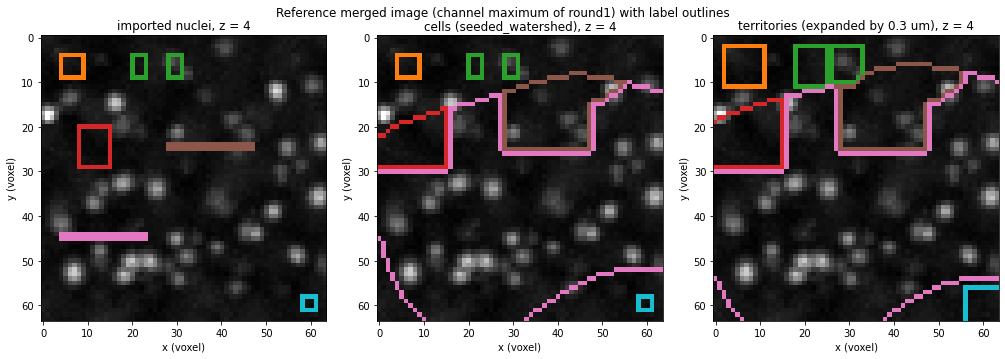

In [9]:
from skimage.segmentation import find_boundaries

Z = 4
stain = fov.images[ROUNDS[0]].max(axis=-1)
panels = (("imported nuclei", imported.labels), ("cells (seeded_watershed)", result.cell_labels),
          (f"territories (expanded by {EXPANSION.distance:g} {EXPANSION.unit})", result.territories))
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), dpi=72, constrained_layout=True)
for axis, (title, labels) in zip(axes, panels):
    axis.imshow(stain[Z], cmap="gray")
    edges = find_boundaries(labels[Z], mode="inner")
    axis.imshow(np.ma.masked_where(~edges, labels[Z]), cmap="tab10", interpolation="nearest", vmin=1,
                vmax=max(NUCLEUS_BOXES))
    axis.set(title=f"{title}, z = {Z}", xlabel="x (voxel)", ylabel="y (voxel)")
fig.suptitle("Reference merged image (channel maximum of round1) with label outlines")
plt.show()

## 6. `FOV.assign` with nuclei

`FOV.assign(config, *, cells="cell", nuclei=None, name="default", population="final",
correspondence=None, checkpoints=None)` takes the molecules from `spot_result` and
`filtering_result` through `molecule_table`, the genes from the codebook and the grid from
`FOV.reference_grid()`, and calls `assign_molecules`
([docs/assignment-contract.md](../../docs/assignment-contract.md), "The assign entry"). `cells`
and `nuclei` name runs of `segmentation_results` or are `SegmentationResult` objects, such as
the `import_labels` result used here for the nuclei. Before sampling, assign checks the config,
the targets, the grid (shape and metadata against the molecule run's grid), that the nuclei lie
on the cell grid, that the label namespaces belong to the molecules' FOV, and that the cell run
was not expanded by segmentation. Each molecule samples the voxel `floor(c + 0.5)` on each axis
(option P1) and gets one status.

With nuclei, correspondence is derived from overlap (option C1: a nucleus is matched to the cell
that holds more than half of it, and any part outside its cell flags it), and cells without a
matched nucleus are excluded by default (option X1). The cell prints the record's provenance and
shows the cell and nucleus tables. On this FOV every watershed cell holds its own seed, so every
cell is `matched` and `available`, and `seed_value_agrees` is true for every nucleus (section 8
shows the other cases).

In [10]:
record = result.record
print("name:", record["name"], " outcome:", record["outcome"], " cell_namespace:", result.cell_namespace)
print("territory_source:", record["territory_source"])
print("grid:", {k: record["grid"][k] for k in ("shape_zyx", "source", "check")},
      " sha256 is the FOV grid's:", record["grid"]["sha256"] == grid.sha256)
inputs = record["inputs"]
print("molecules:", {k: inputs["molecules"][k] for k in ("population", "n")},
      " sha256 is the MoleculeTable's:", inputs["molecules"]["sha256"] == molecules.sha256)
for run, source in (("cells", cell), ("nuclei", imported)):
    entry = inputs[run]
    print(f"{run}:", {k: entry[k] for k in ("run", "target", "geometry", "operations")},
          " labels_sha256 is the run's:", entry["labels_sha256"] == source.record["labels"]["sha256"])
print("correspondence:", inputs["correspondence"])
print("config:", record["config"])
print("sampling:", record["sampling"], " calibration:", record["calibration"], " size_unit:", record["size_unit"])
display(result.cells)
display(result.nuclei)

name: default  outcome: ok  cell_namespace: ["tour","synthetic","FOV_001",null,"cell"]
territory_source: {'run': 'cell', 'target': 'cell', 'origin': 'segmented', 'expanded_by_assign': True}
grid: {'shape_zyx': [8, 64, 64], 'source': 'fov:round1', 'check': 'checked'}  sha256 is the FOV grid's: True
molecules: {'population': 'final', 'n': 63}  sha256 is the MoleculeTable's: True
cells: {'run': 'cell', 'target': 'cell', 'geometry': 'volume', 'operations': []}  labels_sha256 is the run's: True
nuclei: {'run': 'nucleus', 'target': 'nucleus', 'geometry': 'volume', 'operations': []}  labels_sha256 is the run's: True
correspondence: {'source': 'overlap', 'sha256': None}
config: {'expansion': {'distance': 0.3, 'unit': 'um', 'mode': 'planar'}, 'legacy_pixel_expansion': False, 'correspondence': {'match_fraction': 0.5, 'outside_tolerance': 0.1}, 'exclude_cells_without_nucleus': True, 'exclusion_source': 'default', 'exclusion_rationale': 'possible cell residue; not a biological identity'}
sampling:

,cell_id,status,exclusion_reason,size_voxels,expanded_size_voxels,size_physical,expanded_size_physical,centroid_z,centroid_y,centroid_x,expanded_centroid_z,expanded_centroid_y,expanded_centroid_x,n_molecules,n_nuclei,correspondence,correspondence_flags,compartments
0,11,kept,<NA>,108,300,0.3780,1.0500,4.000000,6.500000,6.500000,4.000000,6.500000,6.500000,0,1,matched,,available
1,21,kept,<NA>,72,237,0.2520,0.8295,4.000000,6.500000,21.500000,3.991561,6.443038,21.459916,0,1,matched,,available
2,22,kept,<NA>,72,206,0.2520,0.7210,4.000000,6.500000,29.500000,3.907767,5.902913,29.325243,1,1,matched,,available
3,31,kept,<NA>,986,1292,3.4510,4.5220,4.203854,24.054767,8.448276,4.223684,22.795666,7.954334,0,1,matched,,available
4,51,kept,<NA>,2418,2814,8.4630,9.8490,5.461538,13.064930,40.607113,5.275764,12.407960,40.852523,7,1,matched,,available
5,61,kept,<NA>,19261,20913,67.4135,73.1955,3.469602,38.722444,32.113961,3.431119,39.060106,32.049443,49,1,matched,,available
6,91,kept,<NA>,48,192,0.1680,0.6720,4.000000,59.500000,59.500000,4.000000,59.500000,59.500000,0,1,matched,,available


,nucleus_id,size_voxels,status,cell_id,share_in_cell,share_background,n_cells_overlapped,outside,seed_value_agrees
0,11,108,matched,11,1.0,0.0,1,False,True
1,21,72,matched,21,1.0,0.0,1,False,True
2,22,72,matched,22,1.0,0.0,1,False,True
3,31,400,matched,31,1.0,0.0,1,False,True
4,51,40,matched,51,1.0,0.0,1,False,True
5,61,40,matched,61,1.0,0.0,1,False,True
6,91,48,matched,91,1.0,0.0,1,False,True


`plot_assignment` draws one row of four panels
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Diagnostics"): (1) the
stain in grey scale with the territory outlines in green (the expanded territories, since
assign expanded) and a red dot at each cell's centroid; (2) the same stain and outlines with the
molecules, `assigned` blue, `unassigned` red, and `excluded_cell` orange only when the result
has such molecules (`outside_grid` molecules are not drawn); (3) voxels per cell; (4)
molecules per cell. A volume has two views: `view="z_max"` draws the Z maximum of the stain and
the territories with every molecule, and `view="single_layer"` one plane (by default the middle
plane `Z // 2`, here z = 4) with only the molecules whose sampled voxel lies on it. A plane or
Z=1 result has the Z-maximum view only.

z_max: ['cell centres, Z maximum', 'molecules, Z maximum', 'voxels per cell', 'molecules per cell']


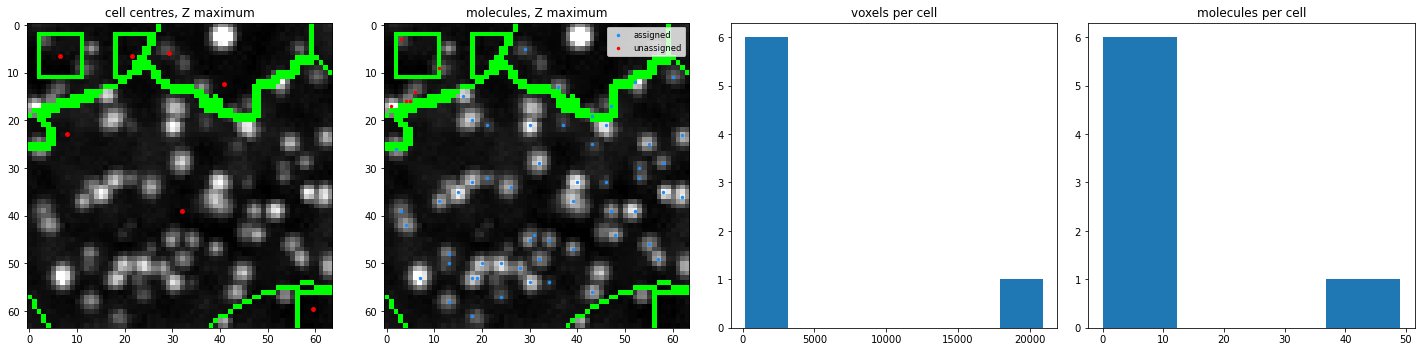

single_layer: ['cell centres, z = 4', 'molecules, z = 4', 'voxels per cell', 'molecules per cell']


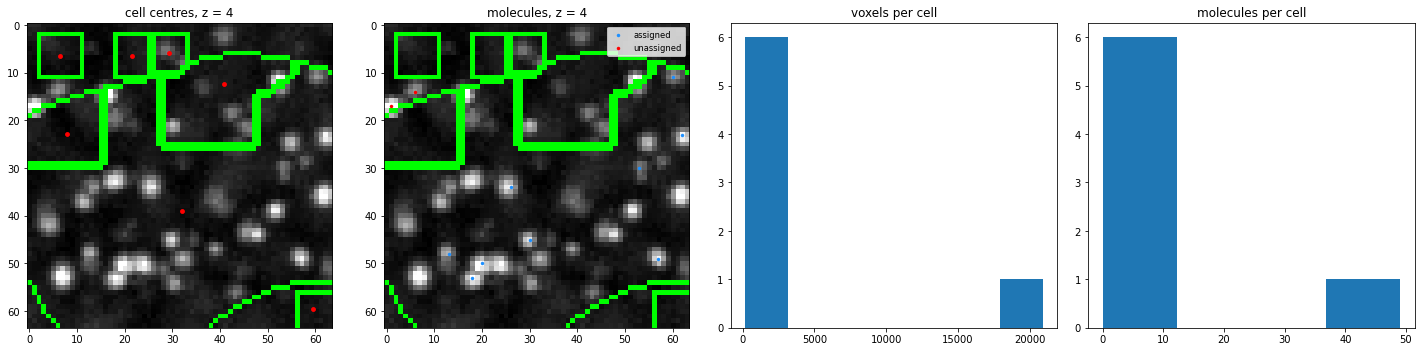

In [11]:
from starfinder.assignment import plot_assignment

for view in ("z_max", "single_layer"):
    figure = plot_assignment(result, image=stain, view=view)
    figure.set_dpi(72)
    print(f"{view}:", [axis.get_title() for axis in figure.axes])
    plt.show()

## 7. Statuses and the count identity

Every input molecule appears once in the molecule table with exactly one status
(`ASSIGNMENT_STATUSES`): `assigned` (in a territory of a kept cell), `unassigned` (in the grid,
in no territory), `excluded_cell` (in the territory of an excluded cell) or `outside_grid` (its
sampled voxel is off the grid). No molecule is dropped, moved to a nearest cell or counted
twice. The counts are an identity
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Count accounting"):

1. the four status counts sum to the number of molecules;
2. the whole-cell counts sum to `assigned`, and per kept cell to its `n_molecules`;
3. for every cell whose compartments are `available` and every gene, `nucleus + cytoplasm =
   whole`; cells whose compartments are not available have no nuclear or cytoplasmic rows, and
   the compartment values of the assigned molecules sum to `assigned`;
4. excluded cells have no count rows, and their `n_molecules` sum to `excluded_cell`;
5. every counted gene is in the gene list.

`AssignmentResult` checks these when it is built. The helper `identities` recomputes them from
the tables and the `summarize_assignment` totals and asserts each one; sections 8 and 9 reuse it.

In [12]:
from starfinder.assignment import ASSIGNMENT_STATUSES, summarize_assignment


def identities(result, n_molecules):
    # Identities 1 to 5 of "Count accounting", recomputed from the tables and the summary; asserted.
    summary = summarize_assignment(result)
    cells, counts, mols = result.cells, result.counts, result.molecules
    kept = cells[cells.status.eq("kept").to_numpy(bool)]
    excluded = cells[~cells.status.eq("kept").to_numpy(bool)]
    available = set(kept.cell_id[kept.compartments.eq("available").to_numpy(bool)].astype(int).tolist())
    by = {c: counts[counts.compartment.eq(c).to_numpy(bool)] for c in ("whole", "nucleus", "cytoplasm")}
    whole_per_cell = by["whole"].groupby(by["whole"].cell_id.astype(int))["count"].sum()
    table = counts.assign(cell_id=counts.cell_id.astype(int), gene_id=counts.gene_id.astype(str)).pivot_table(
        index=["cell_id", "gene_id"], columns="compartment", values="count", aggfunc="sum", fill_value=0)
    for column in ("whole", "nucleus", "cytoplasm"):
        if column not in table:
            table[column] = 0
    on_available = table[table.index.get_level_values(0).isin(available)]
    compartment_cells = set(by["nucleus"].cell_id.astype(int).tolist()) | set(by["cytoplasm"].cell_id.astype(int).tolist())
    not_available = set(kept.cell_id.astype(int).tolist()) - available
    assigned = summary["assigned"]
    assigned_mols = mols[mols.assignment_status.eq("assigned").to_numpy(bool)]
    rows = [
        ("1", "sum of the four status counts = molecules",
         sum(summary["molecules_by_status"][s] for s in ASSIGNMENT_STATUSES), n_molecules),
        ("1", "molecule table rows = molecules", len(mols), n_molecules),
        ("2", "sum of whole-cell counts = assigned", int(by["whole"]["count"].sum()), assigned),
        ("2", "kept cells whose whole counts differ from n_molecules",
         sum(int(whole_per_cell.get(int(c), 0)) != int(n) for c, n in zip(kept.cell_id, kept.n_molecules)), 0),
        ("3", "(cell, gene) of available cells with nucleus + cytoplasm != whole",
         int((on_available["nucleus"] + on_available["cytoplasm"] != on_available["whole"]).sum()), 0),
        ("3", "cells with nuclear or cytoplasmic rows that are not available", len(compartment_cells - available), 0),
        ("3", "nucleus + cytoplasm + whole of kept cells not available = assigned",
         int(by["nucleus"]["count"].sum() + by["cytoplasm"]["count"].sum()
             + whole_per_cell[whole_per_cell.index.isin(list(not_available))].sum()), assigned),
        ("3", "assigned molecules with one compartment value", int(assigned_mols.compartment.notna().sum()), assigned),
        ("4", "count rows of excluded cells",
         int(counts.cell_id.astype(int).isin(excluded.cell_id.astype(int).tolist()).sum()), 0),
        ("4", "n_molecules of excluded cells = excluded_cell", int(excluded.n_molecules.sum()),
         summary["excluded_cell"]),
        ("5", "counted genes outside the gene list", len(set(counts.gene_id.tolist()) - set(result.genes)), 0),
    ]
    frame = pd.DataFrame(rows, columns=["identity", "check", "value", "expected"])
    frame["holds"] = frame.value == frame.expected
    assert frame.holds.all(), frame[~frame.holds]
    return frame, summary


identity_table, summary = identities(result, len(molecules.table))
print("molecules per status:", summary["molecules_by_status"])
print("cells:", summary["cells"], " kept:", summary["cells_kept"], " excluded:", summary["cells_excluded"])
print("assigned molecules by compartment value:", summary["assigned_by_compartment"])
display(identity_table)
matrix, rows = result.matrix("whole")
nuclear, nuclear_rows = result.matrix("nucleus")
print(f"whole-cell matrix: {matrix.shape} {matrix.dtype}, sum {int(matrix.sum())};"
      f" nuclear matrix: {nuclear.shape}, sum {int(nuclear.sum())}")

molecules per status: {'assigned': 57, 'unassigned': 6, 'excluded_cell': 0, 'outside_grid': 0}
cells: 7  kept: 7  excluded: 0
assigned molecules by compartment value: {'nucleus': 1, 'cytoplasm': 56, 'withheld': 0, 'no_nucleus': 0, 'unavailable': 0}


,identity,check,value,expected,holds
0,1,sum of the four status counts = molecules,63,63,True
1,1,molecule table rows = molecules,63,63,True
2,2,sum of whole-cell counts = assigned,57,57,True
3,2,kept cells whose whole counts differ from n_molecules,0,0,True
4,3,"(cell, gene) of available cells with nucleus + cytoplasm != whole",0,0,True
5,3,cells with nuclear or cytoplasmic rows that are not available,0,0,True
6,3,nucleus + cytoplasm + whole of kept cells not available = assigned,57,57,True
7,3,assigned molecules with one compartment value,57,57,True
8,4,count rows of excluded cells,0,0,True
9,4,n_molecules of excluded cells = excluded_cell,0,0,True


whole-cell matrix: (7, 16) int64, sum 57; nuclear matrix: (7, 16), sum 1


## 8. Correspondence statuses, flags and withheld compartments

The watershed cells of the FOV each hold their own nucleus, so they show none of the doubtful
cases. This section uses the hand-built `boxes` fixture of the validation design
([docs/assignment-algorithms.md](../../docs/assignment-algorithms.md), "Fixtures"), whose
geometry gives each rule of the overlap correspondence a case with a known answer (checks A5 to
A11). Its 8×32×32 grid has the same spacing as the FOV. Cells and nuclei are boxes that all
include the plane z = 4:

* cell 1 holds nucleus 11 (27 voxels) entirely;
* cell 2 holds nuclei 21 and 22 (18 voxels each);
* cells 3 and 4 are adjacent, and nucleus 31 (100 voxels) lies 50 / 50 across their border;
* cell 5 holds 6 of the 10 voxels of nucleus 51; the other 4 are in the background;
* cells 6 and 7 are adjacent, and nucleus 61 (10 voxels) lies 8 in cell 6 and 2 in cell 7;
* cell 8 has no nucleus, and nucleus 91 (12 voxels) lies in the background.

The molecules, all at z = 4 except those off the grid: in every cell two molecules outside every
nucleus, and two inside each nucleus part that lies in the cell (none in cell 8); one in the
background; one in nucleus 91; one in the background part of nucleus 51; three off the grid. 38
in all, with four genes. The fixture enters as an external tool's output would: both masks are
written as TIFFs and imported on a grid the caller declares (`source="declared"`), the molecules
are written as a legacy one-based `x, y, z, gene` CSV and read by `molecule_table_from_csv`, and
`assign_molecules` (the function that `FOV.assign` calls) assigns them.

**The rule** ([docs/assignment-contract.md](../../docs/assignment-contract.md), "Nucleus–cell
correspondence"). For nucleus `n` and cell `c`, `f(n, c)` is the share of the nucleus inside the
cell. `n` is `matched` to the cell with the largest share when that share is above
`match_fraction` (0.5, strict); otherwise `ambiguous` when it overlaps a cell, else `no_cell`. A
matched nucleus with a share outside its cell above `outside_tolerance` (0.1 by default, a provisional
value; option C2) is `outside`. Per
cell, the flags `ambiguous_nucleus`, `nucleus_outside_cell` and `foreign_nucleus` make its
compartments **withheld**: its whole-cell counts stay, and its nuclear and cytoplasmic counts are
not produced. Nothing is clipped, merged or re-matched to repair it. `several_nuclei` withholds
nothing.

In [13]:
from starfinder.assignment import CorrespondenceConfig, assign_molecules, molecule_table_from_csv
from starfinder.image import ImageMetadata
from starfinder.segmentation import ReferenceGrid

BOXES_SHAPE = (8, 32, 32)
BOXES_METADATA = ImageMetadata("boxes", spacing_zyx=SPACING_ZYX, spatial_unit="micrometer")
CELL_BOXES = {
    1: ((1, 7), (1, 7), (1, 7)),
    2: ((1, 7), (1, 7), (9, 17)),
    3: ((1, 7), (9, 16), (1, 6)),      # cells 3 and 4 share the border x = 5 | 6
    4: ((1, 7), (9, 16), (6, 11)),
    5: ((1, 7), (9, 16), (14, 20)),
    6: ((1, 7), (19, 25), (1, 10)),    # cells 6 and 7 share the border x = 9 | 10
    7: ((1, 7), (19, 25), (10, 16)),
    8: ((1, 7), (19, 25), (19, 25)),   # no nucleus
}
# ((z, y, x), gene, cell, nucleus), zero-based; cell and nucleus are the values the boxes put there (None off the grid).
BOXES_MOLECULES = (
    ((4, 1, 1), "A", 1, 0), ((4, 6, 6), "B", 1, 0), ((4, 3, 3), "C", 1, 11), ((4, 2, 4), "D", 1, 11),
    ((4, 1, 9), "A", 2, 0), ((4, 6, 16), "B", 2, 0), ((4, 3, 10), "C", 2, 21), ((4, 3, 11), "D", 2, 21),
    ((4, 3, 14), "C", 2, 22), ((4, 3, 15), "C", 2, 22),
    ((4, 9, 1), "A", 3, 0), ((4, 15, 2), "B", 3, 0), ((4, 12, 4), "C", 3, 31), ((4, 12, 5), "D", 3, 31),
    ((4, 9, 10), "A", 4, 0), ((4, 15, 9), "B", 4, 0), ((4, 12, 6), "C", 4, 31), ((4, 12, 7), "D", 4, 31),
    ((4, 9, 15), "A", 5, 0), ((4, 15, 18), "B", 5, 0), ((4, 12, 15), "C", 5, 51), ((4, 12, 16), "D", 5, 51),
    ((4, 19, 1), "A", 6, 0), ((4, 24, 8), "B", 6, 0), ((4, 22, 3), "C", 6, 61), ((4, 22, 5), "D", 6, 61),
    ((4, 19, 14), "A", 7, 0), ((4, 24, 15), "B", 7, 0), ((4, 22, 10), "C", 7, 61), ((4, 22, 11), "D", 7, 61),
    ((4, 20, 20), "A", 8, 0), ((4, 23, 23), "B", 8, 0),
    ((4, 28, 2), "A", 0, 0),                                   # background
    ((4, 30, 30), "B", 0, 91),                                 # inside nucleus 91, in the background
    ((4, 12, 21), "C", 0, 51),                                 # the background part of nucleus 51
    ((8, 4, 4), "A", None, None), ((4, -1, 4), "B", None, None), ((4, 4, 32), "C", None, None),  # off the grid
)
BOXES_SPOTS = json.dumps(["tour", "boxes", "FOV_001", None], separators=(",", ":"))
boxes_grid = ReferenceGrid(BOXES_SHAPE, BOXES_METADATA, "declared")
(WORKSPACE / "boxes").mkdir()


def boxes_labels(target, labels, name):
    # Write a boxes mask as a TIFF and import it on the declared boxes grid.
    path = WORKSPACE / "boxes" / f"{name}.tif"
    save_volume(labels, path, metadata=BOXES_METADATA)
    return import_labels(path, grid=boxes_grid, target=target, label_namespace=label_namespace(BOXES_SPOTS, target))


molecules_csv = WORKSPACE / "boxes" / "molecules.csv"
pd.DataFrame({"x": [p[2] + 1 for p, *_ in BOXES_MOLECULES], "y": [p[1] + 1 for p, *_ in BOXES_MOLECULES],
              "z": [p[0] + 1 for p, *_ in BOXES_MOLECULES], "gene": [g for _, g, *_ in BOXES_MOLECULES]}
             ).to_csv(molecules_csv, index=False)
boxes_molecules = molecule_table_from_csv(molecules_csv, spot_namespace=BOXES_SPOTS, genes=("A", "B", "C", "D"))
boxes_cells = boxes_labels("cell", paint(CELL_BOXES, BOXES_SHAPE), "cells")
boxes_nuclei = boxes_labels("nucleus", paint(NUCLEUS_BOXES, BOXES_SHAPE), "nuclei")


def assign_boxes(nuclei=boxes_nuclei, **config):
    return assign_molecules(boxes_molecules, boxes_cells, grid=boxes_grid, nuclei=nuclei,
                            config=AssignmentConfig(**config))


boxes_default = assign_boxes()
print("boxes:", len(boxes_molecules.table), "molecules,", boxes_cells.n_labels, "cells,", boxes_nuclei.n_labels,
      "nuclei; grid check:", boxes_default.record["grid"]["check"])
sampled = []
for row in boxes_default.molecules.itertuples():
    if row.assignment_status == "outside_grid":
        sampled.append((None, None))
    else:
        sampled.append((int(boxes_cells.labels[row.voxel_z, row.voxel_y, row.voxel_x]), int(row.nucleus_id)))
print("every molecule's sampled cell and nucleus are those stated:",
      sampled == [(c, n) for _, _, c, n in BOXES_MOLECULES])
display(boxes_default.nuclei)
display(boxes_default.cells[["cell_id", "status", "exclusion_reason", "size_voxels", "n_molecules", "n_nuclei",
                             "correspondence", "correspondence_flags", "compartments"]])

boxes: 38 molecules, 8 cells, 7 nuclei; grid check: declared_checked
every molecule's sampled cell and nucleus are those stated: True


,nucleus_id,size_voxels,status,cell_id,share_in_cell,share_background,n_cells_overlapped,outside,seed_value_agrees
0,11,27,matched,1,1.0,0.0,1,False,<NA>
1,21,18,matched,2,1.0,0.0,1,False,<NA>
2,22,18,matched,2,1.0,0.0,1,False,<NA>
3,31,100,ambiguous,<NA>,0.5,0.0,2,False,<NA>
4,51,10,matched,5,0.6,0.4,1,True,<NA>
5,61,10,matched,6,0.8,0.0,2,True,<NA>
6,91,12,no_cell,<NA>,0.0,1.0,0,False,<NA>


,cell_id,status,exclusion_reason,size_voxels,n_molecules,n_nuclei,correspondence,correspondence_flags,compartments
0,1,kept,<NA>,216,4,1,matched,,available
1,2,kept,<NA>,288,6,2,matched,several_nuclei,available
2,3,kept,<NA>,210,4,0,ambiguous,ambiguous_nucleus,withheld
3,4,kept,<NA>,210,4,0,ambiguous,ambiguous_nucleus,withheld
4,5,kept,<NA>,252,4,1,matched,nucleus_outside_cell,withheld
5,6,kept,<NA>,324,4,1,matched,nucleus_outside_cell,withheld
6,7,excluded_no_nucleus,no_matched_nucleus,216,4,0,no_nucleus,foreign_nucleus,no_nucleus
7,8,excluded_no_nucleus,no_matched_nucleus,216,2,0,no_nucleus,,no_nucleus


**A5 to A10, asserted.** The next cell compares the nucleus and cell rows above with the values
derived from the geometry by hand (the code under test does not produce them), then runs the
variants each check names: nucleus 31 split 51 / 49 (one voxel of its cell-4 half moved into
cell 3, at z = 6), `outside_tolerance` 0.0 and 0.5 (the default is 0.1), the exclusion off, and no
nuclei. The expected rows:

| Nucleus | Status | Cell | Size | Share in cell | Share in background | Cells overlapped | Outside |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 11 | matched | 1 | 3·3·3 = 27 | 1.0 | 0.0 | 1 | no |
| 21, 22 | matched | 2 | 3·3·2 = 18 | 1.0 | 0.0 | 1 | no |
| 31 | ambiguous (0.5 is not above 0.5) | none | 5·5·4 = 100 | 0.5 | 0.0 | 2 | no |
| 51 | matched | 5 | 10 | 0.6 | 0.4 | 1 | yes |
| 61 | matched | 6 | 10 | 0.8 | 0.0 | 2 | yes |
| 91 | no_cell | none | 3·2·2 = 12 | 0.0 | 1.0 | 0 | no |

| Cell | Correspondence | Flags | Compartments | Nuclei | Check |
| --- | --- | --- | --- | --- | --- |
| 1 | matched | none | available | 1 | A5 |
| 2 | matched | several_nuclei | available | 2 | A6 |
| 3, 4 | ambiguous | ambiguous_nucleus | withheld (kept) | 0 | A7 |
| 5 | matched | nucleus_outside_cell | withheld | 1 | A8 |
| 6 | matched | nucleus_outside_cell | withheld | 1 | A9 |
| 7 | no_nucleus | foreign_nucleus | no_nucleus (excluded) | 0 | A9, A11 |
| 8 | no_nucleus | none | no_nucleus (excluded) | 0 | A11 |

In [14]:
EXPECTED_NUCLEI = {  # status, cell, size_voxels, share_in_cell, share_background, n_cells_overlapped, outside
    11: ("matched", 1, 27, 1.0, 0.0, 1, False), 21: ("matched", 2, 18, 1.0, 0.0, 1, False),
    22: ("matched", 2, 18, 1.0, 0.0, 1, False), 31: ("ambiguous", None, 100, 0.5, 0.0, 2, False),
    51: ("matched", 5, 10, 0.6, 0.4, 1, True), 61: ("matched", 6, 10, 0.8, 0.0, 2, True),
    91: ("no_cell", None, 12, 0.0, 1.0, 0, False),
}
EXPECTED_CELLS = {  # status, correspondence, flags, compartments, n_nuclei (nuclei given, exclusion by default)
    1: ("kept", "matched", "", "available", 1), 2: ("kept", "matched", "several_nuclei", "available", 2),
    3: ("kept", "ambiguous", "ambiguous_nucleus", "withheld", 0),
    4: ("kept", "ambiguous", "ambiguous_nucleus", "withheld", 0),
    5: ("kept", "matched", "nucleus_outside_cell", "withheld", 1),
    6: ("kept", "matched", "nucleus_outside_cell", "withheld", 1),
    7: ("excluded_no_nucleus", "no_nucleus", "foreign_nucleus", "no_nucleus", 0),
    8: ("excluded_no_nucleus", "no_nucleus", "", "no_nucleus", 0),
}


def nucleus_rows(result):
    return {int(r.nucleus_id): (r.status, None if pd.isna(r.cell_id) else int(r.cell_id), int(r.size_voxels),
                                float(r.share_in_cell), float(r.share_background), int(r.n_cells_overlapped),
                                bool(r.outside)) for r in result.nuclei.itertuples()}


def cell_rows(result):
    return {int(r.cell_id): (r.status, r.correspondence, r.correspondence_flags, r.compartments,
                             None if pd.isna(r.n_nuclei) else int(r.n_nuclei)) for r in result.cells.itertuples()}


def count_cells(result, compartment):
    # The cells that have rows of this compartment in the counts table.
    counts = result.counts
    return sorted(set(counts.cell_id[counts.compartment.eq(compartment).to_numpy(bool)].astype(int).tolist()))


def placed(cells, in_nucleus):
    # Row numbers of the molecules placed in these cells, inside (True) or outside (False) a nucleus.
    return [i for i, (_, _, c, n) in enumerate(BOXES_MOLECULES) if c in cells and (n != 0) == in_nucleus]


def rows_with(result, column, value):
    return result.molecules.index[result.molecules[column].eq(value).fillna(False).to_numpy(bool)].tolist()


print("nucleus rows equal the expected rows:", nucleus_rows(boxes_default) == EXPECTED_NUCLEI)
print("cell rows equal the expected rows:", cell_rows(boxes_default) == EXPECTED_CELLS)
assert nucleus_rows(boxes_default) == EXPECTED_NUCLEI and cell_rows(boxes_default) == EXPECTED_CELLS

split = paint(NUCLEUS_BOXES, BOXES_SHAPE)
assert split[6, 14, 7] == 31 and split[6, 14, 3] == 0
split[6, 14, 7], split[6, 14, 3] = 0, 31          # 51 of nucleus 31's 100 voxels now lie in cell 3
boxes_51_49 = assign_boxes(nuclei=boxes_labels("nucleus", split, "nuclei_51_49"))
strict = assign_boxes(correspondence=CorrespondenceConfig(outside_tolerance=0.0))
tolerant = assign_boxes(correspondence=CorrespondenceConfig(outside_tolerance=0.5))
kept_all = assign_boxes(exclude_cells_without_nucleus=False)
no_nuclei = assign_boxes(nuclei=None)

n31, rows_51_49 = nucleus_rows(boxes_51_49)[31], cell_rows(boxes_51_49)
rows_kept, n61_kept = cell_rows(kept_all), nucleus_rows(kept_all)[61]
nuclear = boxes_default.counts[boxes_default.counts.compartment.eq("nucleus").to_numpy(bool)]
background_51 = boxes_default.molecules.iloc[34]
compartment_rows = lambda result: set(count_cells(result, "nucleus") + count_cells(result, "cytoplasm"))
in_7_8 = kept_all.molecules[kept_all.molecules.cell_id.isin([7, 8]).fillna(False).to_numpy(bool)]
assigned_no_nuclei = no_nuclei.molecules[no_nuclei.molecules.assignment_status.eq("assigned").to_numpy(bool)]
checks = {
    "A5 cell 1: nucleus 11 matched, share 1.0; cell n_nuclei 1, matched, no flag, available":
        nucleus_rows(boxes_default)[11][:4] == ("matched", 1, 27, 1.0)
        and cell_rows(boxes_default)[1][1:] == ("matched", "", "available", 1),
    "A6 cell 2: n_nuclei 2, several_nuclei only, available; nuclear count 4 = 2 (nucleus 21) + 2 (nucleus 22)":
        cell_rows(boxes_default)[2][1:] == ("matched", "several_nuclei", "available", 2)
        and int(nuclear["count"][nuclear.cell_id.astype(int).eq(2).to_numpy(bool)].sum()) == 4 == len(placed({2}, True)),
    "A7 50/50: nucleus 31 ambiguous; cells 3 and 4 ambiguous, ambiguous_nucleus, withheld and kept":
        nucleus_rows(boxes_default)[31][0] == "ambiguous" and all(
            cell_rows(boxes_default)[c][:4] == ("kept", "ambiguous", "ambiguous_nucleus", "withheld") for c in (3, 4)),
    "A7 51/49: nucleus 31 matched to cell 3 and outside; cell 3 matched, nucleus_outside_cell, withheld; "
    "cell 4 no_nucleus with foreign_nucleus, excluded":
        n31[:4] == ("matched", 3, 100, 0.51) and n31[6]
        and rows_51_49[3][:4] == ("kept", "matched", "nucleus_outside_cell", "withheld")
        and rows_51_49[4][:4] == ("excluded_no_nucleus", "no_nucleus", "foreign_nucleus", "no_nucleus"),
    "A8 outside_tolerance 0.0: nucleus 51 matched and outside, cell 5 withheld":
        nucleus_rows(strict)[51][0] == "matched" and nucleus_rows(strict)[51][6]
        and cell_rows(strict)[5][3] == "withheld",
    "A8 the default outside_tolerance 0.1: nucleus 51 (outside share 0.4) matched and outside, cell 5 withheld":
        boxes_default.record["config"]["correspondence"]["outside_tolerance"] == 0.1
        and nucleus_rows(boxes_default)[51][0] == "matched" and nucleus_rows(boxes_default)[51][6]
        and cell_rows(boxes_default)[5][3] == "withheld",
    "A8 outside_tolerance 0.5: nucleus 51 not outside, cell 5 available":
        not nucleus_rows(tolerant)[51][6] and cell_rows(tolerant)[5][2:4] == ("", "available"),
    "A8 the molecule in the background part of nucleus 51 is unassigned with nucleus_id 51":
        background_51.assignment_status == "unassigned" and int(background_51.nucleus_id) == 51
        and pd.isna(background_51.cell_id),
    "A9 exclusion off: nucleus 61 matched to cell 6 (share 0.8) and outside; cell 6 matched, nucleus_outside_cell, "
    "withheld; cell 7 no_nucleus, foreign_nucleus, compartments no_nucleus":
        n61_kept[:2] == ("matched", 6) and n61_kept[3] == 0.8 and n61_kept[6]
        and rows_kept[6][:4] == ("kept", "matched", "nucleus_outside_cell", "withheld")
        and rows_kept[7][:4] == ("kept", "no_nucleus", "foreign_nucleus", "no_nucleus"),
    "A9 cells 6 and 7 keep their whole-cell counts and have no nuclear or cytoplasmic rows":
        {6, 7} <= set(count_cells(kept_all, "whole")) and not {6, 7} & compartment_rows(kept_all),
    "A10 the available cells are 1 and 2, and their nuclear molecules are exactly those placed in their nuclei":
        count_cells(boxes_default, "nucleus") == count_cells(boxes_default, "cytoplasm") == [1, 2]
        and rows_with(boxes_default, "compartment", "nucleus") == placed({1, 2}, True)
        and rows_with(boxes_default, "compartment", "cytoplasm") == placed({1, 2}, False),
    "A10 withheld cells 3, 4, 5 and 6 have no nuclear or cytoplasmic rows (absent, not zero)":
        not {3, 4, 5, 6} & compartment_rows(boxes_default)
        and all(cell_rows(boxes_default)[c][3] == "withheld" for c in (3, 4, 5, 6)),
    "A10 exclusion off: cells 7 and 8 have no compartment rows, their 6 molecules no_nucleus, none cytoplasm":
        not {7, 8} & compartment_rows(kept_all) and len(in_7_8) == 6 and in_7_8.compartment.eq("no_nucleus").all(),
    "A10 without nuclei every assigned molecule is unavailable":
        len(assigned_no_nuclei) == 32 and assigned_no_nuclei.compartment.eq("unavailable").all(),
}
for name, holds in checks.items():
    print(f"{'holds' if holds else 'FAILS'}: {name}")
assert all(checks.values())
for case in (boxes_default, boxes_51_49, strict, tolerant, kept_all, no_nuclei):
    identities(case, len(BOXES_MOLECULES))
print("\nidentities 1 to 5 hold in the six boxes cases (default, 51/49, tolerance 0.0, tolerance 0.5, exclusion off, "
      "no nuclei)")

nucleus rows equal the expected rows: True
cell rows equal the expected rows: True


holds: A5 cell 1: nucleus 11 matched, share 1.0; cell n_nuclei 1, matched, no flag, available
holds: A6 cell 2: n_nuclei 2, several_nuclei only, available; nuclear count 4 = 2 (nucleus 21) + 2 (nucleus 22)
holds: A7 50/50: nucleus 31 ambiguous; cells 3 and 4 ambiguous, ambiguous_nucleus, withheld and kept
holds: A7 51/49: nucleus 31 matched to cell 3 and outside; cell 3 matched, nucleus_outside_cell, withheld; cell 4 no_nucleus with foreign_nucleus, excluded
holds: A8 outside_tolerance 0.0: nucleus 51 matched and outside, cell 5 withheld
holds: A8 the default outside_tolerance 0.1: nucleus 51 (outside share 0.4) matched and outside, cell 5 withheld
holds: A8 outside_tolerance 0.5: nucleus 51 not outside, cell 5 available
holds: A8 the molecule in the background part of nucleus 51 is unassigned with nucleus_id 51
holds: A9 exclusion off: nucleus 61 matched to cell 6 (share 0.8) and outside; cell 6 matched, nucleus_outside_cell, withheld; cell 7 no_nucleus, foreign_nucleus, compartments 


identities 1 to 5 hold in the six boxes cases (default, 51/49, tolerance 0.0, tolerance 0.5, exclusion off, no nuclei)


## 9. The exclusion and its totals

With nuclei, a cell whose correspondence is `no_nucleus` (no matched nucleus and no ambiguous
nucleus over it) is excluded by default (option X1) from the filtered cell table, the counts and
the matrices, with the reason `no_matched_nucleus`
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Exclusion of cells without a
nucleus"). The reason is a filtering rationale (the territory may be cell residue), not a
biological identity, and the record says so. An `ambiguous` cell is not excluded. An excluded
cell keeps its masks and its row in the complete cell table, and its molecules become
`excluded_cell` with its `cell_id`, distinct from `unassigned`, so the totals before and after the
exclusion can both be reported. Without nuclei nothing is excluded. There is no size or count
filter.

The cell checks A11 on `boxes`: with nuclei by default, with `exclude_cells_without_nucleus=False`
and without nuclei, and prints `summarize_assignment`'s totals before and after the exclusion.
Cells 7 and 8 hold 4 and 2 molecules, so the totals must differ by exactly 2 cells and 6
molecules. An excluded cell has no compartment counts, so the nuclear and cytoplasmic totals are
the same before and after.

In [15]:
def exclusion_row(name, result):
    s = summarize_assignment(result)
    before, after = s["exclusion"]["before"], s["exclusion"]["after"]
    return dict(case=name, exclusion_source=result.record["config"]["exclusion_source"],
                cells_before=before["cells"], cells_after=after["cells"], molecules_before=before["molecules"],
                molecules_after=after["molecules"], whole_before=before["whole"], whole_after=after["whole"],
                nucleus_before=before["nucleus"], nucleus_after=after["nucleus"],
                cytoplasm_before=before["cytoplasm"], cytoplasm_after=after["cytoplasm"],
                assigned=s["assigned"], excluded_cell=s["excluded_cell"], unassigned=s["unassigned"],
                outside_grid=s["outside_grid"])


totals = pd.DataFrame([exclusion_row("nuclei, exclusion by default", boxes_default),
                       exclusion_row("nuclei, exclusion off", kept_all),
                       exclusion_row("no nuclei", no_nuclei)]).set_index("case")
display(totals)
excluded = boxes_default.cells[boxes_default.cells.status.eq("excluded_no_nucleus").to_numpy(bool)]
excluded_rows = rows_with(boxes_default, "assignment_status", "excluded_cell")
default_totals = totals.loc["nuclei, exclusion by default"]
config = boxes_default.record["config"]
checks = {
    "default: cells 7 and 8 are excluded_no_nucleus with reason no_matched_nucleus, exclusion_source default":
        excluded.cell_id.astype(int).tolist() == [7, 8] and excluded.exclusion_reason.eq("no_matched_nucleus").all()
        and config["exclusion_source"] == "default"
        and config["exclusion_rationale"] == "possible cell residue; not a biological identity",
    "default: their molecules are excluded_cell with their cell_id, and the cells have no count rows":
        excluded_rows == sorted(placed({7, 8}, False) + placed({7, 8}, True))
        and boxes_default.molecules.cell_id[excluded_rows].astype(int).tolist() == [7, 7, 7, 7, 8, 8]
        and not {7, 8} & set(count_cells(boxes_default, "whole")),
    "default: ambiguous cells 3 and 4 stay kept":
        cell_rows(boxes_default)[3][0] == cell_rows(boxes_default)[4][0] == "kept",
    "default: the complete cell table and the mask keep cells 7 and 8":
        {7, 8} <= set(boxes_default.cells.cell_id.astype(int).tolist())
        and {7, 8} <= set(np.unique(boxes_default.cell_labels).tolist()),
    "default: before and after differ by exactly cells 7 and 8 and their 6 molecules":
        (default_totals.cells_before - default_totals.cells_after,
         default_totals.molecules_before - default_totals.molecules_after) == (2, 6)
        and default_totals.excluded_cell == int(excluded.n_molecules.sum()) == 6,
    "exclusion off: all kept, exclusion_source config; cells 7 and 8 compartments no_nucleus, whole counts only":
        kept_all.cells.status.eq("kept").all() and kept_all.record["config"]["exclusion_source"] == "config"
        and [cell_rows(kept_all)[c][3] for c in (7, 8)] == ["no_nucleus", "no_nucleus"]
        and {7, 8} <= set(count_cells(kept_all, "whole")) and not {7, 8} & compartment_rows(kept_all),
    "every case: before and after have the same five keys and equal nuclear and cytoplasmic totals":
        all(set(s["before"]) == set(s["after"]) == {"cells", "molecules", "whole", "nucleus", "cytoplasm"}
            and all(s["before"][k] == s["after"][k] for k in ("nucleus", "cytoplasm"))
            for s in (summarize_assignment(r)["exclusion"] for r in (boxes_default, kept_all, no_nuclei))),
    "no nuclei: nothing excluded, every cell unavailable":
        no_nuclei.cells.status.eq("kept").all() and no_nuclei.cells.correspondence.eq("unavailable").all()
        and no_nuclei.cells.compartments.eq("unavailable").all() and no_nuclei.nuclei is None,
}
for name, holds in checks.items():
    print(f"{'holds' if holds else 'FAILS'}: {name}")
assert all(checks.values())

,exclusion_source,cells_before,cells_after,molecules_before,molecules_after,whole_before,whole_after,nucleus_before,nucleus_after,cytoplasm_before,cytoplasm_after,assigned,excluded_cell,unassigned,outside_grid
case,,,,,,,,,,,,,,,
"nuclei, exclusion by default",default,8,6,32,26,32,26,6,6,4,4,26,6,3,3
"nuclei, exclusion off",config,8,8,32,32,32,32,6,6,4,4,32,0,3,3
no nuclei,default,8,8,32,32,32,32,0,0,0,0,32,0,3,3


holds: default: cells 7 and 8 are excluded_no_nucleus with reason no_matched_nucleus, exclusion_source default
holds: default: their molecules are excluded_cell with their cell_id, and the cells have no count rows
holds: default: ambiguous cells 3 and 4 stay kept
holds: default: the complete cell table and the mask keep cells 7 and 8
holds: default: before and after differ by exactly cells 7 and 8 and their 6 molecules
holds: exclusion off: all kept, exclusion_source config; cells 7 and 8 compartments no_nucleus, whole counts only
holds: every case: before and after have the same five keys and equal nuclear and cytoplasmic totals
holds: no nuclei: nothing excluded, every cell unavailable


## 10. Persistence and reloading

A checkpointed assignment (`FOV.assign(checkpoints=…)`) writes
`<checkpoint dir>/<fov_id>/assignment/<name>/`: the `molecules`, `cells` (kept and excluded),
`counts` and `nuclei` tables in the checkpoint table format, `assignment.json` (the record) and
the label images it used, by one rule
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Label images of a
checkpointed assignment"): a label image **saved under its run** (written by
`FOV.segment(checkpoints=…)` or loaded by `FOV.load_segmentation` from the same root, with an
unchanged file) is linked, not copied; every other label image is written into the folder. For
this tour's case the rows of that table are:

* cell labels, saved under its run: `segmentation/cell/labels.tif`, linked;
* nucleus labels, unsaved (the `import_labels` result of section 4): `nucleus_labels.tif`,
  written;
* expanded territories, computed by assign: `territories.tif`, written.

The nuclei given to `FOV.assign` are the `import_labels` result, not the plan's `nucleus` run;
naming the run instead (`nuclei="nucleus"`) would link `segmentation/nucleus/labels.tif`. So the
folder holds no `cell_labels.tif`, and it holds `nucleus_labels.tif`. Every link in `assignment.json` carries the file's
SHA-256, and `FOV.load_assignment` checks every one (a missing or changed file raises naming the
path and both hashes). The cell runs the third call again with checkpoints, under the name
`checkpointed`, and checks the files, the links and their hashes, and that the files of
`FOV.run` and `FOV.segment` are unchanged.

In [16]:
before = files_under(CHECKPOINTS.directory)
with timed("call 3 again: FOV.assign with checkpoints"):
    fov.assign(AssignmentConfig(expansion=EXPANSION), nuclei=imported, name="checkpointed", checkpoints=CHECKPOINTS)
checkpointed = fov.assignment_results["checkpointed"]
after = files_under(CHECKPOINTS.directory)
folder = CHECKPOINTS.directory / "FOV_001" / "assignment" / "checkpointed"
written = sorted(p for p in after if p not in before)
print("files written by FOV.assign:", written)
assert {Path(p).name for p in written} == {"assignment.json", "molecules.csv", "cells.csv", "counts.csv",
                                            "nuclei.csv", "territories.tif", "nucleus_labels.tif"}
print("files of FOV.run and FOV.segment unchanged:", {p: after[p] for p in before} == before)
assert {p: after[p] for p in before} == before
saved = json.loads((folder / "assignment.json").read_text())
links = {"inputs.cells.file": saved["inputs"]["cells"]["file"], "inputs.nuclei.file": saved["inputs"]["nuclei"]["file"],
         "expansion.original": dict(saved["expansion"]["original"], sha256=saved["expansion"]["original"]["file_sha256"]),
         "expansion.expanded": dict(saved["expansion"]["expanded"], sha256=saved["expansion"]["expanded"]["file_sha256"]),
         **{f"files.{key}": value for key, value in saved["files"].items()}}
link_rows = []
for name, link in links.items():
    path = (folder / link["path"]).resolve()
    link_rows.append(dict(link=name, path=link["path"],
                          file=path.relative_to(CHECKPOINTS.directory.resolve()).as_posix() if path.is_file() else None,
                          sha256_equals_file=path.is_file() and file_sha256(path) == link["sha256"]))
link_table = pd.DataFrame(link_rows)
display(link_table)
expected_links = {"inputs.cells.file": "FOV_001/segmentation/cell/labels.tif",
                  "inputs.nuclei.file": "FOV_001/assignment/checkpointed/nucleus_labels.tif",
                  "expansion.original": "FOV_001/segmentation/cell/labels.tif",
                  "expansion.expanded": "FOV_001/assignment/checkpointed/territories.tif"}
print("every link resolves to a file whose SHA-256 equals the link's:", bool(link_table.sha256_equals_file.all()))
print("the label links are those of this case:",
      {r.link: r.file for r in link_table.itertuples() if r.link in expected_links} == expected_links)
assert link_table.sha256_equals_file.all()
assert {r.link: r.file for r in link_table.itertuples() if r.link in expected_links} == expected_links
print("saved_under_run: cells", saved["inputs"]["cells"]["saved_under_run"], " nuclei",
      saved["inputs"]["nuclei"]["saved_under_run"], "  no cell_labels.tif:", not (folder / "cell_labels.tif").exists())

files written by FOV.assign: ['FOV_001/assignment/checkpointed/assignment.json', 'FOV_001/assignment/checkpointed/cells.csv', 'FOV_001/assignment/checkpointed/counts.csv', 'FOV_001/assignment/checkpointed/molecules.csv', 'FOV_001/assignment/checkpointed/nuclei.csv', 'FOV_001/assignment/checkpointed/nucleus_labels.tif', 'FOV_001/assignment/checkpointed/territories.tif']
files of FOV.run and FOV.segment unchanged: True


,link,path,file,sha256_equals_file
0,inputs.cells.file,../../segmentation/cell/labels.tif,FOV_001/segmentation/cell/labels.tif,True
1,inputs.nuclei.file,nucleus_labels.tif,FOV_001/assignment/checkpointed/nucleus_labels.tif,True
2,expansion.original,../../segmentation/cell/labels.tif,FOV_001/segmentation/cell/labels.tif,True
3,expansion.expanded,territories.tif,FOV_001/assignment/checkpointed/territories.tif,True
4,files.molecules,molecules.csv,FOV_001/assignment/checkpointed/molecules.csv,True
5,files.cells,cells.csv,FOV_001/assignment/checkpointed/cells.csv,True
6,files.counts,counts.csv,FOV_001/assignment/checkpointed/counts.csv,True
7,files.nuclei,nuclei.csv,FOV_001/assignment/checkpointed/nuclei.csv,True
8,files.nucleus_labels,nucleus_labels.tif,FOV_001/assignment/checkpointed/nucleus_labels.tif,True
9,files.territories,territories.tif,FOV_001/assignment/checkpointed/territories.tif,True


every link resolves to a file whose SHA-256 equals the link's: True
the label links are those of this case: True
saved_under_run: cells True  nuclei False   no cell_labels.tif: True


The reload starts from a new FOV object of the same dataset, which holds no images and no
results. `FOV.load_segmentation("cell")` reads the run's `labels.tif` and `segmentation.json` and
checks their hashes; `FOV.load_assignment("checkpointed")` reads the folder and the linked
`segmentation/cell/labels.tif`, checks every recorded hash and rebuilds the tables with their
recorded dtypes. The cell compares both with the originals: label arrays and records equal, tables
equal under `assert_frame_equal(check_exact=True)`.

In [17]:
from pandas.testing import assert_frame_equal

reloaded_fov = dataset.fov("FOV_001")
print("the new FOV object holds images:", bool(reloaded_fov.images), " segmentation results:",
      list(reloaded_fov.segmentation_results), " assignment results:", list(reloaded_fov.assignment_results))
with timed("FOV.load_segmentation and FOV.load_assignment"):
    reloaded_cell = reloaded_fov.load_segmentation("cell", checkpoints=CHECKPOINTS)
    reloaded = reloaded_fov.load_assignment("checkpointed", checkpoints=CHECKPOINTS)
same_segmentation = {
    "labels": np.array_equal(reloaded_cell.labels, cell.labels) and reloaded_cell.labels.dtype == cell.labels.dtype,
    "grid": reloaded_cell.grid == cell.grid,
    "target, geometry, namespace": (reloaded_cell.target, reloaded_cell.geometry, reloaded_cell.label_namespace)
                                   == (cell.target, cell.geometry, cell.label_namespace),
    "record": reloaded_cell.record == cell.record,
}
print("FOV.load_segmentation('cell') equals the run:", same_segmentation)
for name in ("molecules", "cells", "counts", "nuclei"):
    assert_frame_equal(getattr(reloaded, name), getattr(checkpointed, name), check_exact=True)
same_assignment = {
    "tables (check_exact)": True,
    "cell_labels": np.array_equal(reloaded.cell_labels, checkpointed.cell_labels),
    "territories": np.array_equal(reloaded.territories, checkpointed.territories),
    "nucleus_labels": np.array_equal(reloaded.nucleus_labels, checkpointed.nucleus_labels),
    "genes, cell_namespace": (reloaded.genes, reloaded.cell_namespace) == (checkpointed.genes,
                                                                           checkpointed.cell_namespace),
    "record": reloaded.record == checkpointed.record,
}
print("FOV.load_assignment('checkpointed') equals the result:", same_assignment)
assert all(same_segmentation.values()) and all(same_assignment.values())
for name in ("molecules", "cells", "counts", "nuclei"):
    assert_frame_equal(getattr(checkpointed, name), getattr(result, name), check_exact=True)
print("the checkpointed tables equal those of the in-memory call of section 5: True")

the new FOV object holds images: False  segmentation results: []  assignment results: []


FOV.load_segmentation('cell') equals the run: {'labels': True, 'grid': True, 'target, geometry, namespace': True, 'record': True}
FOV.load_assignment('checkpointed') equals the result: {'tables (check_exact)': True, 'cell_labels': True, 'territories': True, 'nucleus_labels': True, 'genes, cell_namespace': True, 'record': True}
the checkpointed tables equal those of the in-memory call of section 5: True


## 11. What §2.10 receives

Assignment is FOV-local: it reads one FOV's molecules and label images on that FOV's reference
grid. It reads no tile configuration, computes no global coordinate, decides no overlap
ownership and matches no cell across FOVs; stitching is §2.10's
([docs/assignment-contract.md](../../docs/assignment-contract.md), "Boundary with §2.10"). What
§2.10 receives per FOV:

* the cell table, keyed by `(cell_namespace, cell_id)`, with centroids (original and expanded) in
  zero-based index coordinates of the reference grid, sizes, status and exclusion reason,
  correspondence, nuclei per cell, flags and compartments;
* the grid (shape and `ImageMetadata`, whose origin, spacing and direction place the FOV);
* the original and expanded territory label files with their SHA-256, for overlap and cross-FOV
  matching;
* the molecule table with each molecule's status and cell key, and the count tables.

In [18]:
print("cell_namespace:", checkpointed.cell_namespace)
display(checkpointed.cells[["cell_id", "status", "exclusion_reason", "centroid_z", "centroid_y", "centroid_x",
                            "expanded_centroid_z", "expanded_centroid_y", "expanded_centroid_x", "size_voxels",
                            "expanded_size_voxels", "correspondence", "n_nuclei", "compartments"]].round(3))
print("grid:", saved["grid"]["shape_zyx"], saved["grid"]["metadata"])
for key in ("expansion.original", "expansion.expanded"):
    print(f"{key}: {links[key]['path']}  sha256 {links[key]['sha256']}")
display(checkpointed.molecules[["spot_namespace", "spot_id", "z", "y", "x", "gene_id", "assignment_status",
                                "cell_id", "in_expansion", "nucleus_id", "compartment"]].head(8))
print("count table:", checkpointed.counts.shape, list(checkpointed.counts.columns))

cell_namespace: ["tour","synthetic","FOV_001",null,"cell"]


,cell_id,status,exclusion_reason,centroid_z,centroid_y,centroid_x,expanded_centroid_z,expanded_centroid_y,expanded_centroid_x,size_voxels,expanded_size_voxels,correspondence,n_nuclei,compartments
0,11,kept,<NA>,4.000,6.500,6.500,4.000,6.500,6.500,108,300,matched,1,available
1,21,kept,<NA>,4.000,6.500,21.500,3.992,6.443,21.460,72,237,matched,1,available
2,22,kept,<NA>,4.000,6.500,29.500,3.908,5.903,29.325,72,206,matched,1,available
3,31,kept,<NA>,4.204,24.055,8.448,4.224,22.796,7.954,986,1292,matched,1,available
4,51,kept,<NA>,5.462,13.065,40.607,5.276,12.408,40.853,2418,2814,matched,1,available
5,61,kept,<NA>,3.470,38.722,32.114,3.431,39.060,32.049,19261,20913,matched,1,available
6,91,kept,<NA>,4.000,59.500,59.500,4.000,59.500,59.500,48,192,matched,1,available


grid: [8, 64, 64] {'frame_id': '["calibrated-development-v1-clean-balanced","synthetic","FOV_001","formed"]/reference', 'spacing_zyx': [0.35, 0.1, 0.1], 'origin_zyx': None, 'direction_zyx': None, 'spatial_unit': 'micrometer'}
expansion.original: ../../segmentation/cell/labels.tif  sha256 80ebb711e74993d0a56f1c37ee9bd071f266e2701829ad25401ed562ec198009
expansion.expanded: territories.tif  sha256 efed8120f5df5321dad59de45223b6469e06adf3cf93c16113290b6094580bca


,spot_namespace,spot_id,z,y,x,gene_id,assignment_status,cell_id,in_expansion,nucleus_id,compartment
0,"[""tour"",""synthetic"",""FOV_001"",null]",0,1.0,35.0,15.0,balanced-03,assigned,61,False,0,cytoplasm
1,"[""tour"",""synthetic"",""FOV_001"",null]",1,3.0,39.0,52.0,balanced-02,assigned,61,False,0,cytoplasm
2,"[""tour"",""synthetic"",""FOV_001"",null]",2,6.0,21.0,46.0,balanced-02,assigned,51,False,0,cytoplasm
3,"[""tour"",""synthetic"",""FOV_001"",null]",3,3.0,36.0,62.0,balanced-04,assigned,61,False,0,cytoplasm
4,"[""tour"",""synthetic"",""FOV_001"",null]",4,2.0,50.0,24.0,balanced-02,assigned,61,False,0,cytoplasm
5,"[""tour"",""synthetic"",""FOV_001"",null]",5,4.0,50.0,20.0,balanced-04,assigned,61,False,0,cytoplasm
6,"[""tour"",""synthetic"",""FOV_001"",null]",6,6.0,20.0,18.0,balanced-01,assigned,61,False,0,cytoplasm
7,"[""tour"",""synthetic"",""FOV_001"",null]",7,5.0,25.0,55.0,balanced-03,assigned,61,False,0,cytoplasm


count table: (46, 4) ['cell_id', 'gene_id', 'compartment', 'count']


## 12. Checks and limits

**How §2.9 is checked.** The two golden tests (`test_segmentation_golden.py`,
`test_assignment_golden.py`) pin the legacy behavior with SHA-256 digests. The engineering
validation design ([docs/assignment-algorithms.md](../../docs/assignment-algorithms.md),
"Engineering validation design" and "Implemented checks (W-318)") has 14 segmentation checks (L1
to L14) and 20 assignment checks (A1 to A20) on hand-built fixtures, with exact tolerances fixed
before the run. They run in the default test tier except the `learned` checks (StarDist,
Cellpose and model files on CPU), L12 (CPU against GPU, GPU batches only) and A19 (`slow`). The
validation measures no segmentation or assignment quality. The cell reads the implemented-checks
table from the page and lists the rows this notebook also demonstrates on its own fixtures: L9
and L13 (section 4), A2 (section 7), A5 to A11 (sections 8 and 9) and A15 (section 10).

In [19]:
def markdown_table(text, heading):
    # The first Markdown table after heading, as a DataFrame of its cells.
    lines = text[text.index(heading):].splitlines()
    start = next(i for i, line in enumerate(lines) if line.startswith("| #"))
    rows = []
    for line in lines[start:]:
        if not line.startswith("|"):
            break
        rows.append([cell.strip() for cell in line.strip("|").split(" | ")])
    return pd.DataFrame(rows[2:], columns=rows[0])


implemented = markdown_table((REPOSITORY / "docs" / "assignment-algorithms.md").read_text(),
                             "### Implemented checks (W-318)")
print("rows:", len(implemented), " L:", int(implemented["#"].str.startswith("L").sum()),
      " A:", int(implemented["#"].str.startswith("A").sum()))
SHOWN = {"L9": "4", "L13": "4", "A2": "7", "A5": "8", "A6": "8", "A7": "8", "A8": "8", "A9": "8", "A10": "8",
         "A11": "9", "A15": "10"}
shown = implemented[implemented["#"].isin(list(SHOWN))].copy()
shown.insert(1, "notebook section", shown["#"].map(SHOWN))
shown["Module and tests"] = shown["Module and tests"].str.replace("`", "")
with pd.option_context("display.max_colwidth", 110):
    display(shown)

rows: 34  L: 14  A: 20


,#,notebook section,Module and tests,Tier
8,L9,4,"test_segmentation_segment.py, test_l9_every_seed_keeps_its_value_and_no_other_value_appears, test_l9_no_se...",default
12,L13,4,"test_segmentation_persistence.py, test_l13_*",default
15,A2,7,"test_assignment.py, test_a2_boxes_statuses_and_accounting; test_assignment_golden.py, test_the_package_sta...",default
18,A5,8,"test_assignment.py, test_a5_to_a7_nucleus_table_and_cell_rows",default
19,A6,8,"test_assignment.py, test_a5_to_a7_nucleus_table_and_cell_rows, test_a6_several_nuclei_count_both",default
20,A7,8,"test_assignment.py, test_a5_to_a7_nucleus_table_and_cell_rows, test_a7_a_nucleus_split_51_49",default
21,A8,8,"test_assignment.py, test_a8_a_nucleus_outside_its_cell, test_the_default_correspondence_is_option_c2, test...",default
22,A9,8,"test_assignment.py, test_a9_a_foreign_nucleus",default
23,A10,8,"test_assignment.py, test_a10_compartment_partition",default
24,A11,9,"test_assignment.py, test_a11_exclusion_and_its_statuses",default


**Known limits** (from the pages; [docs/assignment-algorithms.md](../../docs/assignment-algorithms.md),
"Limitations", and [docs/segmentation-algorithms.md](../../docs/segmentation-algorithms.md),
"Limitations"):

* this notebook is synthetic only: a hand-built nucleus mask and the seeded watershed on the
  amplicon signal of a molecular scene that holds no cells. Its cells show how the calls fit
  together, not how well any method finds cells; that needs annotation (W-123) and E04;
* the watershed's `sigma_um` default (1.5 µm) is provisional, and the voxel size here is declared
  for the demonstration;
* the correspondence thresholds (`match_fraction` 0.5, `outside_tolerance` 0.1) are not fitted
  to data. Exact containment (0.0) withheld the compartments of nearly every cell of the W-320
  culture crop; the default 0.1 (option C2) is provisional, from that one crop without
  annotation;
* every assignment resource figure in the pages is code-derived; nothing was measured on a whole
  FOV, and whole-FOV volumetric expansion passes the 4 GiB target without blocks or tiling;
* no learned model runs here; the learned methods are checked by the `learned` tests on CPU;
* stitching, global coordinates and cross-FOV matching are §2.10's.

**Size and cost of this notebook.** The bound is 32×64×64 voxels, four channels and four rounds.
The next cell checks every image and label array the notebook holds (the scene's rounds, the
FOV's resident rounds, the masks, every segmentation and assignment label image, and the `boxes`
images) against it. It then prints the wall-clock time of the slower steps, measured by `timed`
at one thread on this host. These times vary between runs and are indicative only. They are the
only printed numbers that do.

In [20]:
BOUND_ZYX, BOUND_CHANNELS, BOUND_ROUNDS = (32, 64, 64), 4, 4
held = {
    "scene round images (ZYXC)": list(scene.rounds.values()),
    "FOV resident round images (ZYXC)": list(fov.images.values()),
    "hand-built nucleus mask": [nucleus_mask],
    "segmentation label images": [r.labels for r in fov.segmentation_results.values()]
                                 + [imported.labels, reloaded_cell.labels],
    "assignment label images": [a for r in (*fov.assignment_results.values(), reloaded)
                                for a in (r.cell_labels, r.territories, r.nucleus_labels) if a is not None],
    "boxes label images": [a for r in (boxes_default, boxes_51_49, tolerant, kept_all, no_nuclei)
                           for a in (r.cell_labels, r.territories, r.nucleus_labels) if a is not None],
}
audit = pd.DataFrame([dict(arrays=name, count=len(arrays), shapes=", ".join(sorted({str(a.shape) for a in arrays})),
                           within_bound=all(all(n <= b for n, b in zip(a.shape[:3], BOUND_ZYX))
                                            and (a.ndim == 3 or a.shape[3] <= BOUND_CHANNELS) for a in arrays))
                      for name, arrays in held.items()])
display(audit)
print("rounds of the scene:", len(scene.rounds), " resident rounds:", len(fov.images))
print("every array within 32x64x64 voxels and 4 channels:", bool(audit.within_bound.all()),
      " within 4 rounds:", len(scene.rounds) <= BOUND_ROUNDS and len(fov.images) <= BOUND_ROUNDS)
assert audit.within_bound.all() and len(scene.rounds) <= BOUND_ROUNDS
print("learned backends imported:", {name: name in sys.modules for name in LEARNED_BACKENDS})
print("\nwall-clock time of the slower steps (one thread, this host; indicative, varies between runs):")
for label, seconds in TIMINGS.items():
    print(f"  {seconds:6.2f} s  {label}")

,arrays,count,shapes,within_bound
0,scene round images (ZYXC),4,"(8, 64, 64, 4)",True
1,FOV resident round images (ZYXC),4,"(8, 64, 64, 4)",True
2,hand-built nucleus mask,1,"(8, 64, 64)",True
3,segmentation label images,4,"(8, 64, 64)",True
4,assignment label images,9,"(8, 64, 64)",True
5,boxes label images,9,"(8, 32, 32)",True


rounds of the scene: 4  resident rounds: 4
every array within 32x64x64 voxels and 4 channels: True  within 4 rounds: True
learned backends imported: {'stardist': False, 'tensorflow': False, 'cellpose': False, 'torch': False}

wall-clock time of the slower steps (one thread, this host; indicative, varies between runs):
    0.23 s  generate the scene (clean, seed 103, 8x64x64x4, 4 rounds)
    0.24 s  call 1: FOV.run with checkpoints
    0.03 s  call 2: FOV.segment (import and seeded_watershed) with checkpoints
    0.06 s  call 3: FOV.assign with the expansion and nuclei
    0.09 s  call 3 again: FOV.assign with checkpoints
    0.04 s  FOV.load_segmentation and FOV.load_assignment


## 13. Clean up

The notebook wrote only inside its temporary workspace: the dataset's reference image, the
checkpoints of the three calls, the hand-built masks and the `boxes` files. The last cell reports
what it wrote and removes the workspace.

In [21]:
written_files = [path for path in WORKSPACE.rglob("*") if path.is_file()]
print(f"{len(written_files)} files, {sum(p.stat().st_size for p in written_files) / 2**10:.0f} KiB written, all under",
      sorted({p.relative_to(WORKSPACE).parts[0] for p in written_files}))
_workspace.cleanup()
print("workspace removed:", not WORKSPACE.exists())

28 files, 936 KiB written, all under ['boxes', 'checkpoints', 'data', 'masks']
workspace removed: True
